# 1. Environment, paths, metadata download
(Downloads the Google Sheet into a pandas DataFrame and saves a backup with a timestamp)

In [92]:
import os
import glob
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Path to your network NWB files
DATA_DIR = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types"

# 2. Local directory for saving results
RESULTS_DIR = r"../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 3. Google Sheet Metadata Export URL
SHEET_ID = "1CpN3jsWR5c84a57sGSgWtrgvnnLRKjxJgxjQg8Alx1I"
GID = "1820785849"
METADATA_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

# 4. Download Google Sheet and Save Timestamped Backup
try:
    metadata_df = pd.read_csv(METADATA_URL)
    print(f"✅ Successfully loaded Google Sheet metadata ({len(metadata_df)} rows).")
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    meta_filename = f"2025_STR_MSN_analysis_{timestamp}.csv"
    
    os.makedirs("../data/metadata", exist_ok=True)
    meta_save_path = os.path.join("../data/metadata", meta_filename)
    metadata_df.to_csv(meta_save_path, index=False)
    print(f"💾 Saved metadata backup to: {meta_save_path}")
    
except Exception as e:
    print(f"❌ Error downloading Google Sheet: {e}")
    metadata_df = pd.DataFrame()

# 5. Find all NWB files
nwb_files = glob.glob(os.path.join(DATA_DIR, "*.nwb"))
print(f"📁 Found {len(nwb_files)} NWB files in network folder.")

✅ Successfully loaded Google Sheet metadata (208 rows).
💾 Saved metadata backup to: ../data/metadata\2025_STR_MSN_analysis_20261001_115414.csv
📁 Found 229 NWB files in network folder.


# 2. Feature Extractor & Universal NWB Loader
(Includes dynamic current-channel searching to fix NaNs in MIES NWB 1.0 files)

In [133]:
#v14 - PRODUCTION EXTRACTOR WITH EXPLICIT COLUMN UNITS & DUAL SAG METRICS
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half in ms."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike in mV."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def find_main_stimulus_pulse(i, sampling_rate=25000.0, min_duration_ms=100.0):
    """
    Locates the main stimulus pulse window by identifying contiguous blocks 
    longer than min_duration_ms. Ignores brief t=0 ms test pulses and switching noise.
    """
    base_len = min(1000, len(i) // 10)
    i_base = np.mean(i[:base_len])
    
    active_mask = np.abs(i - i_base) > 5.0
    if not np.any(active_mask):
        return None, None, 0.0, i_base
        
    diffs = np.diff(active_mask.astype(int))
    starts = np.where(diffs == 1)[0] + 1
    ends = np.where(diffs == -1)[0] + 1
    
    if active_mask[0]: starts = np.insert(starts, 0, 0)
    if active_mask[-1]: ends = np.append(ends, len(i))
    
    min_samples = int((min_duration_ms / 1000.0) * sampling_rate)
    valid_blocks = [(s, e) for s, e in zip(starts, ends) if (e - s) >= min_samples]
    
    if not valid_blocks:
        return None, None, 0.0, i_base
        
    p_start, p_end = max(valid_blocks, key=lambda b: b[1] - b[0])
    p_len = p_end - p_start
    i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
    delta_i = i_step - i_base
    
    return p_start, p_end, delta_i, i_base


def extract_labnotebook_hardware_metrics(file_path):
    """
    Extracts ground-truth hardware metrics from MIES HDF5 labnotebook.
      - bridge_balance(mOhms): MultiClamp Commander setting (Bridge Bal Value)
      - cell_access(mOhms): Voltage-Clamp test pulse access resistance (TP Peak Resistance)
      - holding_current(pA): Active MultiClamp bias current (I-Clamp Holding Level -> TP Baseline pA)
    """
    bridge_bal_val = np.nan
    vc_tp_peak_res = np.nan
    vc_series_res = np.nan
    gen_tp_peak_res = np.nan
    i_clamp_hold = np.nan
    tp_baseline_pa = np.nan

    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return {
                    "cell_access(mOhms)": np.nan,
                    "bridge_balance(mOhms)": np.nan,
                    "holding_current(pA)": 0.0
                }
            
            ln_group = f['general/labnotebook']
            dev_name = list(ln_group.keys())[0]
            dev_group = ln_group[dev_name]
            
            if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) 
                        for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_col_idx(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    return matches[0] if matches else None

                clamp_mode_idx = get_col_idx('Clamp Mode')
                bridge_bal_idx = get_col_idx('Bridge Bal Value')
                series_res_idx = get_col_idx('Series Resistance')
                tp_peak_idx = get_col_idx('TP Peak Resistance')
                hold_level_idx = get_col_idx('I-Clamp Holding Level')
                tp_baseline_idx = get_col_idx('TP Baseline pA')

                # 1. Bridge Balance Value (Unfiltered by row-level clamp_mode)
                if bridge_bal_idx is not None:
                    p_bb = vals[:, bridge_bal_idx, 0] if vals.ndim == 3 else vals[:, bridge_bal_idx]
                    valid_bb = p_bb[~np.isnan(p_bb) & (p_bb > 0.5) & (p_bb < 150.0)]
                    if len(valid_bb) > 0:
                        bridge_bal_val = np.median(valid_bb)

                # 2. General TP Peak Resistance (Fallback)
                if tp_peak_idx is not None:
                    p_tp = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                    valid_tp = p_tp[~np.isnan(p_tp) & (p_tp > 0.5) & (p_tp < 150.0)]
                    if len(valid_tp) > 0:
                        gen_tp_peak_res = np.median(valid_tp)

                # 3. Mode-Filtered VC Sweeps (Clamp Mode 0)
                if clamp_mode_idx is not None:
                    clamp_modes = vals[:, clamp_mode_idx, 0] if vals.ndim == 3 else vals[:, clamp_mode_idx]
                    vc_mask = (clamp_modes == 0)

                    if series_res_idx is not None:
                        p_sr = vals[:, series_res_idx, 0] if vals.ndim == 3 else vals[:, series_res_idx]
                        valid_sr = p_sr[vc_mask & ~np.isnan(p_sr) & (p_sr > 0.5) & (p_sr < 150.0)]
                        if len(valid_sr) > 0: vc_series_res = np.median(valid_sr)

                    if tp_peak_idx is not None:
                        p_tp_vc = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                        valid_tp_vc = p_tp_vc[vc_mask & ~np.isnan(p_tp_vc) & (p_tp_vc > 0.5) & (p_tp_vc < 150.0)]
                        if len(valid_tp_vc) > 0: vc_tp_peak_res = np.median(valid_tp_vc)

                # 4. Holding Current
                if hold_level_idx is not None:
                    p_hold = vals[:, hold_level_idx, 0] if vals.ndim == 3 else vals[:, hold_level_idx]
                    valid_hold = p_hold[~np.isnan(p_hold)]
                    if len(valid_hold) > 0: i_clamp_hold = np.median(valid_hold)

                if tp_baseline_idx is not None:
                    p_base = vals[:, tp_baseline_idx, 0] if vals.ndim == 3 else vals[:, tp_baseline_idx]
                    valid_base = p_base[~np.isnan(p_base)]
                    if len(valid_base) > 0: tp_baseline_pa = np.median(valid_base)

    except Exception:
        pass

    cell_access = np.nan
    if pd.notna(vc_tp_peak_res):
        cell_access = vc_tp_peak_res
    elif pd.notna(vc_series_res):
        cell_access = vc_series_res
    elif pd.notna(gen_tp_peak_res):
        cell_access = gen_tp_peak_res

    bridge_balance = bridge_bal_val if pd.notna(bridge_bal_val) else np.nan

    holding_current = 0.0
    if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
        holding_current = i_clamp_hold
    elif pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
        holding_current = tp_baseline_pa

    return {
        "cell_access(mOhms)": cell_access,
        "bridge_balance(mOhms)": bridge_balance,
        "holding_current(pA)": holding_current
    }


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_frac_list, sag_ratio_list, tau_list = [], [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            # Discard dead / railed traces early
            if np.max(np.abs(v)) > 500.0:
                continue

            # Contiguous step finder
            p_start, p_end, delta_i, i_base = find_main_stimulus_pulse(i)

            if p_start is not None and p_end is not None and (p_end - p_start) > 100:
                p_len = p_end - p_start
                sweep_duration_sec = t[min(p_end, len(t) - 1)] - t[p_start]
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:  # Ignore LSB noise (-4.17 pA)
                    r_in = (abs(delta_v) / abs(delta_i)) * 1000.0
                    
                    if 10.0 < r_in < 3500.0:
                        r_in_list.append(r_in)
                    
                        v_deflection = abs(v_trough - v_base)
                        if v_deflection > 0.5:
                            sag_frac = abs(v_trough - v_steady) / v_deflection
                            if 0.0 <= sag_frac <= 1.0:
                                sag_frac_list.append(sag_frac)
                                sag_ratio_list.append(1.0 - sag_frac)
                            
                        v_target = v_base + 0.632 * delta_v
                        tau_idx = np.where(v[p_start:p_end] <= v_target if delta_v < 0 else v[p_start:p_end] >= v_target)[0]
                        if len(tau_idx) > 0:
                            tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                            if 0.5 < tau_ms < 200.0:
                                tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec if sweep_duration_sec > 0 else 0
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[min(p_end, len(t) - 1)])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance(mOhms)": r_in_final,
            "tau(ms)": tau_final,
            "capacitance(pF)": capacitance_final,
            "sag_fraction": np.median(sag_frac_list) if sag_frac_list else np.nan,
            "sag_ratio": np.median(sag_ratio_list) if sag_ratio_list else np.nan,
            
            "f_i_curve_slope(Hz/pA)": fi_slope,
            "max_firing_rate(Hz)": max_firing_rate,
            
            "rheobase_sweep_stim_amp(pA)": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t(s)": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t(s)": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v(mV)": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i(pA)": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v(mV)": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i(pA)": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude(mV)": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width(ms)": rheo_ap_width,
            "rheobase_sweep_upstroke(V/s)": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke(V/s)": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v(mV)": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v(mV)": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v(mV)": rheo_adp_v,
            "rheobase_sweep_latency(ms)": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi(ms)": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi(ms)": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate(Hz)": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp(pA)": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v(mV)": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v(mV)": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width(ms)": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Hardware Metrics
    hw_metrics = extract_labnotebook_hardware_metrics(file_path)
    feats["holding_current(pA)"] = hw_metrics["holding_current(pA)"]
    feats["bridge_balance(mOhms)"] = hw_metrics["bridge_balance(mOhms)"]
    feats["cell_access(mOhms)"] = hw_metrics["cell_access(mOhms)"]
    
    return feats

In [125]:
#v13 - PRODUCTION EXTRACTOR WITH CONTIGUOUS PULSE FINDER & EXPANDED SUBTHRESHOLD BOUNDS
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def find_main_stimulus_pulse(i, sampling_rate=25000.0, min_duration_ms=100.0):
    """
    Locates the main stimulus pulse window by identifying contiguous blocks 
    longer than min_duration_ms. Ignores brief t=0 ms test pulses and switching noise.
    """
    base_len = min(1000, len(i) // 10)
    i_base = np.mean(i[:base_len])
    
    active_mask = np.abs(i - i_base) > 5.0
    if not np.any(active_mask):
        return None, None, 0.0, i_base
        
    diffs = np.diff(active_mask.astype(int))
    starts = np.where(diffs == 1)[0] + 1
    ends = np.where(diffs == -1)[0] + 1
    
    if active_mask[0]: starts = np.insert(starts, 0, 0)
    if active_mask[-1]: ends = np.append(ends, len(i))
    
    min_samples = int((min_duration_ms / 1000.0) * sampling_rate)
    valid_blocks = [(s, e) for s, e in zip(starts, ends) if (e - s) >= min_samples]
    
    if not valid_blocks:
        return None, None, 0.0, i_base
        
    # Pick the longest contiguous pulse block (main current step)
    p_start, p_end = max(valid_blocks, key=lambda b: b[1] - b[0])
    p_len = p_end - p_start
    i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
    delta_i = i_step - i_base
    
    return p_start, p_end, delta_i, i_base


def extract_labnotebook_hardware_metrics(file_path):
    """
    Extracts ground-truth hardware metrics from MIES HDF5 labnotebook.
      - bridge_balance(mOhms): MultiClamp Commander setting (Bridge Bal Value)
      - cell_access(mOhms): Voltage-Clamp test pulse access resistance (TP Peak Resistance)
      - holding_current(pA): Active MultiClamp bias current (I-Clamp Holding Level -> TP Baseline pA)
    """
    bridge_bal_val = np.nan
    vc_tp_peak_res = np.nan
    vc_series_res = np.nan
    gen_tp_peak_res = np.nan
    i_clamp_hold = np.nan
    tp_baseline_pa = np.nan

    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return {
                    "cell_access(mOhms)": np.nan,
                    "bridge_balance(mOhms)": np.nan,
                    "holding_current(pA)": 0.0
                }
            
            ln_group = f['general/labnotebook']
            dev_name = list(ln_group.keys())[0]
            dev_group = ln_group[dev_name]
            
            if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) 
                        for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_col_idx(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    return matches[0] if matches else None

                clamp_mode_idx = get_col_idx('Clamp Mode')
                bridge_bal_idx = get_col_idx('Bridge Bal Value')
                series_res_idx = get_col_idx('Series Resistance')
                tp_peak_idx = get_col_idx('TP Peak Resistance')
                hold_level_idx = get_col_idx('I-Clamp Holding Level')
                tp_baseline_idx = get_col_idx('TP Baseline pA')

                # 1. Bridge Balance Value (Unfiltered by row-level clamp_mode)
                if bridge_bal_idx is not None:
                    p_bb = vals[:, bridge_bal_idx, 0] if vals.ndim == 3 else vals[:, bridge_bal_idx]
                    valid_bb = p_bb[~np.isnan(p_bb) & (p_bb > 0.5) & (p_bb < 150.0)]
                    if len(valid_bb) > 0:
                        bridge_bal_val = np.median(valid_bb)

                # 2. General TP Peak Resistance (Fallback)
                if tp_peak_idx is not None:
                    p_tp = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                    valid_tp = p_tp[~np.isnan(p_tp) & (p_tp > 0.5) & (p_tp < 150.0)]
                    if len(valid_tp) > 0:
                        gen_tp_peak_res = np.median(valid_tp)

                # 3. Mode-Filtered VC Sweeps (Clamp Mode 0)
                if clamp_mode_idx is not None:
                    clamp_modes = vals[:, clamp_mode_idx, 0] if vals.ndim == 3 else vals[:, clamp_mode_idx]
                    vc_mask = (clamp_modes == 0)

                    if series_res_idx is not None:
                        p_sr = vals[:, series_res_idx, 0] if vals.ndim == 3 else vals[:, series_res_idx]
                        valid_sr = p_sr[vc_mask & ~np.isnan(p_sr) & (p_sr > 0.5) & (p_sr < 150.0)]
                        if len(valid_sr) > 0: vc_series_res = np.median(valid_sr)

                    if tp_peak_idx is not None:
                        p_tp_vc = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                        valid_tp_vc = p_tp_vc[vc_mask & ~np.isnan(p_tp_vc) & (p_tp_vc > 0.5) & (p_tp_vc < 150.0)]
                        if len(valid_tp_vc) > 0: vc_tp_peak_res = np.median(valid_tp_vc)

                # 4. Holding Current
                if hold_level_idx is not None:
                    p_hold = vals[:, hold_level_idx, 0] if vals.ndim == 3 else vals[:, hold_level_idx]
                    valid_hold = p_hold[~np.isnan(p_hold)]
                    if len(valid_hold) > 0: i_clamp_hold = np.median(valid_hold)

                if tp_baseline_idx is not None:
                    p_base = vals[:, tp_baseline_idx, 0] if vals.ndim == 3 else vals[:, tp_baseline_idx]
                    valid_base = p_base[~np.isnan(p_base)]
                    if len(valid_base) > 0: tp_baseline_pa = np.median(valid_base)

    except Exception:
        pass

    # Assign final values
    cell_access = np.nan
    if pd.notna(vc_tp_peak_res):
        cell_access = vc_tp_peak_res
    elif pd.notna(vc_series_res):
        cell_access = vc_series_res
    elif pd.notna(gen_tp_peak_res):
        cell_access = gen_tp_peak_res

    bridge_balance = bridge_bal_val if pd.notna(bridge_bal_val) else np.nan

    holding_current = 0.0
    if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
        holding_current = i_clamp_hold
    elif pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
        holding_current = tp_baseline_pa

    return {
        "cell_access(mOhms)": cell_access,
        "bridge_balance(mOhms)": bridge_balance,
        "holding_current(pA)": holding_current
    }


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            # Discard dead / railed traces early
            if np.max(np.abs(v)) > 500.0:
                continue

            # Robust pulse window detection (ignores brief test pulses at t=0 ms)
            p_start, p_end, delta_i, i_base = find_main_stimulus_pulse(i)

            if p_start is not None and p_end is not None and (p_end - p_start) > 100:
                p_len = p_end - p_start
                sweep_duration_sec = t[min(p_end, len(t) - 1)] - t[p_start]
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:  # Ignore LSB noise (-4.17 pA)
                    # Absolute magnitude ratio to handle DAQ sign/polarity flips safely
                    r_in = (abs(delta_v) / abs(delta_i)) * 1000.0
                    
                    # Expanded upper bound (3500 MOhms) to recover high-Rin cells while dropping dead traces
                    if 10.0 < r_in < 3500.0:
                        r_in_list.append(r_in)
                    
                        v_deflection = abs(v_trough - v_base)
                        if v_deflection > 1.0:
                            sag_val = abs(v_trough - v_steady) / v_deflection
                            if 0.0 <= sag_val <= 1.0:
                                sag_list.append(sag_val)
                            
                        v_target = v_base + 0.632 * delta_v
                        tau_idx = np.where(v[p_start:p_end] <= v_target if delta_v < 0 else v[p_start:p_end] >= v_target)[0]
                        if len(tau_idx) > 0:
                            tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                            if 0.5 < tau_ms < 200.0:
                                tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec if sweep_duration_sec > 0 else 0
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[min(p_end, len(t) - 1)])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Labnotebook Hardware Metrics
    hw_metrics = extract_labnotebook_hardware_metrics(file_path)
    feats["holding_current(pA)"] = hw_metrics["holding_current(pA)"]
    feats["bridge_balance(mOhms)"] = hw_metrics["bridge_balance(mOhms)"]
    feats["cell_access(mOhms)"] = hw_metrics["cell_access(mOhms)"]
    
    return feats

In [107]:
#v12 - FIXED HARDWARE METRICS EXTRACTOR (BRIDGE BALANCE & CELL ACCESS)
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_labnotebook_hardware_metrics(file_path):
    """
    Extracts ground-truth hardware metrics from MIES HDF5 labnotebook.
    
    - bridge_balance(mOhms): MultiClamp Commander software setting (Bridge Bal Value)
    - cell_access(mOhms): True access resistance from Voltage-Clamp test pulses (TP Peak Resistance)
    - holding_current(pA): MultiClamp DC bias setting (I-Clamp Holding Level -> TP Baseline pA)
    """
    bridge_bal_val = np.nan
    vc_tp_peak_res = np.nan
    vc_series_res = np.nan
    gen_tp_peak_res = np.nan
    i_clamp_hold = np.nan
    tp_baseline_pa = np.nan

    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return {
                    "cell_access(mOhms)": np.nan,
                    "bridge_balance(mOhms)": np.nan,
                    "holding_current(pA)": 0.0
                }
            
            ln_group = f['general/labnotebook']
            dev_name = list(ln_group.keys())[0]
            dev_group = ln_group[dev_name]
            
            if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) 
                        for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_col_idx(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    return matches[0] if matches else None

                clamp_mode_idx = get_col_idx('Clamp Mode')
                bridge_bal_idx = get_col_idx('Bridge Bal Value')
                series_res_idx = get_col_idx('Series Resistance')
                tp_peak_idx = get_col_idx('TP Peak Resistance')
                hold_level_idx = get_col_idx('I-Clamp Holding Level')
                tp_baseline_idx = get_col_idx('TP Baseline pA')

                # 1. Bridge Balance Value (Unfiltered by row-level clamp_mode)
                if bridge_bal_idx is not None:
                    p_bb = vals[:, bridge_bal_idx, 0] if vals.ndim == 3 else vals[:, bridge_bal_idx]
                    valid_bb = p_bb[~np.isnan(p_bb) & (p_bb > 0.5) & (p_bb < 150.0)]
                    if len(valid_bb) > 0:
                        bridge_bal_val = np.median(valid_bb)

                # 2. General TP Peak Resistance (Fallback)
                if tp_peak_idx is not None:
                    p_tp = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                    valid_tp = p_tp[~np.isnan(p_tp) & (p_tp > 0.5) & (p_tp < 150.0)]
                    if len(valid_tp) > 0:
                        gen_tp_peak_res = np.median(valid_tp)

                # 3. Mode-Filtered VC Sweeps (Clamp Mode 0)
                if clamp_mode_idx is not None:
                    clamp_modes = vals[:, clamp_mode_idx, 0] if vals.ndim == 3 else vals[:, clamp_mode_idx]
                    vc_mask = (clamp_modes == 0)

                    if series_res_idx is not None:
                        p_sr = vals[:, series_res_idx, 0] if vals.ndim == 3 else vals[:, series_res_idx]
                        valid_sr = p_sr[vc_mask & ~np.isnan(p_sr) & (p_sr > 0.5) & (p_sr < 150.0)]
                        if len(valid_sr) > 0: vc_series_res = np.median(valid_sr)

                    if tp_peak_idx is not None:
                        p_tp_vc = vals[:, tp_peak_idx, 0] if vals.ndim == 3 else vals[:, tp_peak_idx]
                        valid_tp_vc = p_tp_vc[vc_mask & ~np.isnan(p_tp_vc) & (p_tp_vc > 0.5) & (p_tp_vc < 150.0)]
                        if len(valid_tp_vc) > 0: vc_tp_peak_res = np.median(valid_tp_vc)

                # 4. Holding Current (I-Clamp Holding / TP Baseline)
                if hold_level_idx is not None:
                    p_hold = vals[:, hold_level_idx, 0] if vals.ndim == 3 else vals[:, hold_level_idx]
                    valid_hold = p_hold[~np.isnan(p_hold)]
                    if len(valid_hold) > 0: i_clamp_hold = np.median(valid_hold)

                if tp_baseline_idx is not None:
                    p_base = vals[:, tp_baseline_idx, 0] if vals.ndim == 3 else vals[:, tp_baseline_idx]
                    valid_base = p_base[~np.isnan(p_base)]
                    if len(valid_base) > 0: tp_baseline_pa = np.median(valid_base)

    except Exception:
        pass

    # --- FINAL METRIC ASSIGNMENTS ---
    # Cell Access: VC Test Pulse -> VC Series Res -> General Test Pulse
    cell_access = np.nan
    if pd.notna(vc_tp_peak_res):
        cell_access = vc_tp_peak_res
    elif pd.notna(vc_series_res):
        cell_access = vc_series_res
    elif pd.notna(gen_tp_peak_res):
        cell_access = gen_tp_peak_res

    # Bridge Balance: MultiClamp Commander active setting
    bridge_balance = bridge_bal_val if pd.notna(bridge_bal_val) else np.nan

    # Holding Current: MultiClamp Holding Level -> TP Baseline
    holding_current = 0.0
    if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
        holding_current = i_clamp_hold
    elif pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
        holding_current = tp_baseline_pa

    return {
        "cell_access(mOhms)": cell_access,
        "bridge_balance(mOhms)": bridge_balance,
        "holding_current(pA)": holding_current
    }


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Labnotebook Hardware Metrics
    hw_metrics = extract_labnotebook_hardware_metrics(file_path)
    feats["holding_current(pA)"] = hw_metrics["holding_current(pA)"]
    feats["bridge_balance(mOhms)"] = hw_metrics["bridge_balance(mOhms)"]
    feats["cell_access(mOhms)"] = hw_metrics["cell_access(mOhms)"]
    
    return feats

In [103]:
#v11 - CLAMP-MODE FILTERED HARDWARE METRICS
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_labnotebook_hardware_metrics(file_path):
    """
    Extracts hardware metrics strictly separating Voltage Clamp (VC, Mode 0) 
    and Current Clamp (IC, Mode 1) sweeps.
    
    - cell_access(mOhms): Measured in VC mode (vc_tp_peak_res -> vc_series_res)
    - bridge_balance(mOhms): MultiClamp Commander Bridge Bal Value from IC mode
    - holding_current(pA): MultiClamp I-Clamp Holding Level -> TP Baseline pA
    """
    vc_series_res = np.nan
    vc_tp_peak_res = np.nan
    ic_bridge_bal = np.nan
    ic_tp_peak_res = np.nan
    i_clamp_hold = np.nan
    tp_baseline_pa = np.nan

    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return {
                    "cell_access(mOhms)": np.nan,
                    "bridge_balance(mOhms)": np.nan,
                    "holding_current(pA)": 0.0
                }
            
            ln_group = f['general/labnotebook']
            dev_name = list(ln_group.keys())[0]
            dev_group = ln_group[dev_name]
            
            if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) 
                        for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_col_idx(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    return matches[0] if matches else None

                clamp_mode_idx = get_col_idx('Clamp Mode')
                bridge_bal_idx = get_col_idx('Bridge Bal Value')
                series_res_idx = get_col_idx('Series Resistance')
                tp_peak_idx = get_col_idx('TP Peak Resistance')
                hold_level_idx = get_col_idx('I-Clamp Holding Level')
                tp_baseline_idx = get_col_idx('TP Baseline pA')

                if clamp_mode_idx is not None:
                    clamp_modes = vals[:, clamp_mode_idx, 0] if vals.ndim == 3 else vals[:, clamp_mode_idx]
                    vc_mask = (clamp_modes == 0)
                    ic_mask = (clamp_modes == 1)

                    def get_stat(col_idx, mode_mask=None, filter_range=True):
                        if col_idx is None: return np.nan
                        p_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                        mask = ~np.isnan(p_vals)
                        if filter_range:
                            mask = mask & (p_vals > 0.5) & (p_vals < 150.0)
                        if mode_mask is not None:
                            mask = mask & mode_mask
                        valid = p_vals[mask]
                        return np.median(valid) if len(valid) > 0 else np.nan

                    # VC Sweeps (Clamp Mode 0) -> Cell Access
                    vc_series_res = get_stat(series_res_idx, vc_mask)
                    vc_tp_peak_res = get_stat(tp_peak_idx, vc_mask)

                    # IC Sweeps (Clamp Mode 1) -> Bridge Balance
                    ic_bridge_bal = get_stat(bridge_bal_idx, ic_mask)
                    ic_tp_peak_res = get_stat(tp_peak_idx, ic_mask)

                    # Holding Current (All Sweeps)
                    i_clamp_hold = get_stat(hold_level_idx, filter_range=False)
                    tp_baseline_pa = get_stat(tp_baseline_idx, filter_range=False)

    except Exception:
        pass

    # 1. Cell Access: Prioritizes Voltage Clamp sweeps
    cell_access = np.nan
    if pd.notna(vc_tp_peak_res):
        cell_access = vc_tp_peak_res
    elif pd.notna(vc_series_res):
        cell_access = vc_series_res
    elif pd.notna(ic_tp_peak_res):
        cell_access = ic_tp_peak_res

    # 2. Bridge Balance: Strictly Current Clamp software setting
    bridge_balance = ic_bridge_bal if pd.notna(ic_bridge_bal) else np.nan

    # 3. Holding Current
    holding_current = 0.0
    if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
        holding_current = i_clamp_hold
    elif pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
        holding_current = tp_baseline_pa

    return {
        "cell_access(mOhms)": cell_access,
        "bridge_balance(mOhms)": bridge_balance,
        "holding_current(pA)": holding_current
    }


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Labnotebook Hardware Metrics (Filtered by Clamp Mode)
    hw_metrics = extract_labnotebook_hardware_metrics(file_path)
    feats["holding_current(pA)"] = hw_metrics["holding_current(pA)"]
    feats["bridge_balance(mOhms)"] = hw_metrics["bridge_balance(mOhms)"]
    feats["cell_access(mOhms)"] = hw_metrics["cell_access(mOhms)"]
    
    return feats

In [93]:
#v10 - PRODUCTION EXTRACTOR WITH EXPLICIT BRIDGE BALANCE, CELL ACCESS & HOLDING CURRENT
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_labnotebook_hardware_metrics(file_path):
    """
    Extracts ground-truth hardware metrics directly from MIES HDF5 labnotebook.
    Returns dictionary with:
      - bridge_balance(mOhms): MultiClamp Commander active Bridge Bal Value
      - cell_access(mOhms): 3-tier fallback (Bridge Bal -> Series Resistance -> TP Peak Resistance)
      - holding_current(pA): MultiClamp I-Clamp Holding Level -> TP Baseline pA
    """
    bridge_bal = np.nan
    series_res = np.nan
    tp_peak_res = np.nan
    i_clamp_hold = np.nan
    tp_baseline_pa = np.nan
    
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' in f:
                ln_group = f['general/labnotebook']
                for dev in ln_group.keys():
                    dev_group = ln_group[dev]
                    if 'numericalKeys' not in dev_group or 'numericalValues' not in dev_group:
                        continue
                        
                    raw_keys = dev_group['numericalKeys'][:]
                    keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                    vals = dev_group['numericalValues'][:]
                    
                    def get_key_median(key_name):
                        matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                        if not matches: return np.nan
                        col_idx = matches[0]
                        param_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                        valid_vals = param_vals[~np.isnan(param_vals)]
                        return np.median(valid_vals) if len(valid_vals) > 0 else np.nan

                    def get_key_median_filtered(key_name):
                        matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                        if not matches: return np.nan
                        col_idx = matches[0]
                        param_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                        valid_vals = param_vals[~np.isnan(param_vals) & (param_vals > 0.5) & (param_vals < 120.0)]
                        return np.median(valid_vals) if len(valid_vals) > 0 else np.nan

                    bridge_bal = get_key_median_filtered('Bridge Bal Value')
                    series_res = get_key_median_filtered('Series Resistance')
                    tp_peak_res = get_key_median_filtered('TP Peak Resistance')
                    i_clamp_hold = get_key_median('I-Clamp Holding Level')
                    tp_baseline_pa = get_key_median('TP Baseline pA')
                    
    except Exception:
        pass

    # Cell Access Hierarchy
    cell_access = np.nan
    if pd.notna(bridge_bal):
        cell_access = bridge_bal
    elif pd.notna(series_res):
        cell_access = series_res
    elif pd.notna(tp_peak_res):
        cell_access = tp_peak_res

    # Holding Current Hierarchy
    holding_current = 0.0
    if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
        holding_current = i_clamp_hold
    elif pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
        holding_current = tp_baseline_pa

    return {
        "bridge_balance(mOhms)": bridge_bal,
        "cell_access(mOhms)": cell_access,
        "holding_current(pA)": holding_current
    }


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Labnotebook Hardware Metrics
    hw_metrics = extract_labnotebook_hardware_metrics(file_path)
    feats["holding_current(pA)"] = hw_metrics["holding_current(pA)"]
    feats["bridge_balance(mOhms)"] = hw_metrics["bridge_balance(mOhms)"]
    feats["cell_access(mOhms)"] = hw_metrics["cell_access(mOhms)"]
    
    return feats

In [89]:
#v9 - PRODUCTION EXTRACTOR WITH LABNOTEBOOK CELL ACCESS & HOLDING CURRENT
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_cell_access_from_labnotebook(file_path):
    """
    Extracts ground-truth cell_access (mOhms) from MIES HDF5 labnotebook.
    Priority:
      1. Bridge Bal Value (I-Clamp hardware setting)
      2. Series Resistance (V-Clamp hardware setting)
      3. TP Peak Resistance (MIES automated background test-pulse access resistance)
    """
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return np.nan
            
            ln_group = f['general/labnotebook']
            for dev in ln_group.keys():
                dev_group = ln_group[dev]
                if 'numericalKeys' not in dev_group or 'numericalValues' not in dev_group:
                    continue
                    
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_key_median(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    if not matches: return np.nan
                    col_idx = matches[0]
                    param_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                    valid_vals = param_vals[~np.isnan(param_vals) & (param_vals > 0.5) & (param_vals < 120.0)]
                    return np.median(valid_vals) if len(valid_vals) > 0 else np.nan

                bridge_bal = get_key_median('Bridge Bal Value')
                if pd.notna(bridge_bal): return bridge_bal
                    
                series_res = get_key_median('Series Resistance')
                if pd.notna(series_res): return series_res
                    
                tp_peak_res = get_key_median('TP Peak Resistance')
                if pd.notna(tp_peak_res): return tp_peak_res
                    
    except Exception:
        pass
        
    return np.nan


def extract_holding_current_from_labnotebook(file_path):
    """
    Extracts ground-truth holding current (pA) from MIES HDF5 labnotebook.
    Priority:
      1. I-Clamp Holding Level (MultiClamp Commander active DC bias current)
      2. TP Baseline pA (Background test pulse baseline current at rest)
    """
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return np.nan
            
            ln_group = f['general/labnotebook']
            for dev in ln_group.keys():
                dev_group = ln_group[dev]
                if 'numericalKeys' not in dev_group or 'numericalValues' not in dev_group:
                    continue
                    
                raw_keys = dev_group['numericalKeys'][:]
                keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                vals = dev_group['numericalValues'][:]
                
                def get_key_median(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    if not matches: return np.nan
                    col_idx = matches[0]
                    param_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                    valid_vals = param_vals[~np.isnan(param_vals)]
                    return np.median(valid_vals) if len(valid_vals) > 0 else np.nan

                # Tier 1: MultiClamp Commander explicit I-Clamp Holding Level
                i_clamp_hold = get_key_median('I-Clamp Holding Level')
                if pd.notna(i_clamp_hold) and abs(i_clamp_hold) > 0.01:
                    return i_clamp_hold
                    
                # Tier 2: Background Test Pulse Baseline Current
                tp_baseline_pa = get_key_median('TP Baseline pA')
                if pd.notna(tp_baseline_pa) and abs(tp_baseline_pa) > 0.01:
                    return tp_baseline_pa
                    
    except Exception:
        pass
        
    return 0.0  # Unbiased I=0 recording


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Ground-truth Labnotebook Hardware Metrics
    feats["holding_current(pA)"] = extract_holding_current_from_labnotebook(file_path)
    feats["cell_access(mOhms)"] = extract_cell_access_from_labnotebook(file_path)
    
    return feats

In [82]:
#v8 - FINAL WITH LABNOTEBOOK CELL ACCESS
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor

def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"

def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan

def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan

def extract_cell_access_from_labnotebook(file_path):
    """
    Extracts ground-truth cell_access (mOhms) from MIES HDF5 labnotebook.
    Priority:
      1. Bridge Bal Value (I-Clamp hardware setting)
      2. Series Resistance (V-Clamp hardware setting)
      3. TP Peak Resistance (MIES automated background test-pulse access resistance)
    """
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' not in f:
                return np.nan
            
            ln_group = f['general/labnotebook']
            for dev in ln_group.keys():
                dev_group = ln_group[dev]
                if 'numericalKeys' not in dev_group or 'numericalValues' not in dev_group:
                    continue
                    
                # Decode labnotebook keys
                raw_keys = dev_group['numericalKeys'][:]
                if raw_keys.ndim > 1:
                    keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in raw_keys[0]]
                else:
                    keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in raw_keys]
                
                vals = dev_group['numericalValues'][:]
                
                # Helper to fetch median non-zero value for a key
                def get_key_median(key_name):
                    matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                    if not matches:
                        return np.nan
                    col_idx = matches[0]
                    param_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                    valid_vals = param_vals[~np.isnan(param_vals) & (param_vals > 0.5) & (param_vals < 120.0)]
                    return np.median(valid_vals) if len(valid_vals) > 0 else np.nan

                # Tier 1: Bridge Bal Value
                bridge_bal = get_key_median('Bridge Bal Value')
                if pd.notna(bridge_bal):
                    return bridge_bal
                    
                # Tier 2: Series Resistance
                series_res = get_key_median('Series Resistance')
                if pd.notna(series_res):
                    return series_res  # Fixed typo here
                    
                # Tier 3: TP Peak Resistance (MIES automated test pulse access measurement)
                tp_peak_res = get_key_median('TP Peak Resistance')
                if pd.notna(tp_peak_res):
                    return tp_peak_res
                    
    except Exception:
        pass
        
    return np.nan

def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents = []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            stim_comment = ""
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    stim_comment = str(cand_obj.attrs.get('comments', '')) + " " + str(cand_obj.attrs.get('description', ''))
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # --- Holding Current Extraction ---
            i_hold_val = i_base
            if abs(i_hold_val) < 0.1 and stim_comment:
                i_hold_match = re.search(r"(?:I-Clamp Holding Level|Autobias Ibias):\s*([-\d\.]+)\s*pA", stim_comment)
                if i_hold_match: i_hold_val = float(i_hold_match.group(1))
            holding_currents.append(i_hold_val)

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }

def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    
    # Add Ground-Truth Labnotebook Cell Access
    feats["cell_access(mOhms)"] = extract_cell_access_from_labnotebook(file_path)
    
    return feats

In [ ]:
#v7 USE THIS ONE
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents, access_res_list = [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            stim_comment = ""
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    stim_comment = str(cand_obj.attrs.get('comments', '')) + " " + str(cand_obj.attrs.get('description', ''))
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # --- Holding Current Extraction ---
            i_hold_val = i_base
            if abs(i_hold_val) < 0.1 and stim_comment:
                i_hold_match = re.search(r"(?:I-Clamp Holding Level|Autobias Ibias):\s*([-\d\.]+)\s*pA", stim_comment)
                if i_hold_match: i_hold_val = float(i_hold_match.group(1))
            holding_currents.append(i_hold_val)

            # --- Ground-Truth Access Resistance (Header Bridge Bal / VC Test Pulses Only) ---
            if stim_comment:
                ra_match = re.search(r"(?:Bridge Bal Value|Series Resistance):\s*([-\d\.]+)\s*M", stim_comment)
                if ra_match:
                    ra_val = float(ra_match.group(1))
                    if 5.0 <= ra_val <= 80.0: access_res_list.append(ra_val)

            # Voltage Clamp Test Pulse Calculation
            if np.max(np.abs(v)) > 2.0 and np.max(np.abs(v)) < 15.0 and np.max(np.abs(i)) > 50.0:
                v_step_mv = np.max(np.abs(v - np.mean(v[:500])))
                i_peak_pa = np.max(np.abs(i - i_base))
                if i_peak_pa > 0:
                    ra_vc = (v_step_mv / i_peak_pa) * 1000.0
                    if 5.0 <= ra_vc <= 80.0: access_res_list.append(ra_vc)

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            "cell_access(mOhms)": np.median(access_res_list) if access_res_list else np.nan,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    return feats

# 3. Single Cell Feature Test

In [135]:
import pandas as pd
import numpy as np

# Select a mix of test files (preferring known active/spiking cells if available)
test_files = [f for f in nwb_files if "850495" in f or "880646" in f][:3]
if not test_files:
    test_files = nwb_files[:3]

test_rows = []
for fpath in test_files:
    feats = process_file_universal(fpath, metadata_df if 'metadata_df' in globals() else pd.DataFrame())
    test_rows.append(feats)

df_test_check = pd.DataFrame(test_rows)

print("=" * 100)
print("📊 #v14 PRE-BATCH VERIFICATION SUMMARY")
print("=" * 100)

# Display essential passive, active, and hardware columns with updated #v14 unit headers
display_cols = [
    "cell_name", 
    "v_rest(mV)", 
    "holding_current(pA)", 
    "cell_access(mOhms)", 
    "bridge_balance(mOhms)", 
    "input_resistance(mOhms)", 
    "tau(ms)", 
    "capacitance(pF)", 
    "sag_fraction", 
    "sag_ratio", 
    "rheobase_sweep_stim_amp(pA)",
    "rheobase_sweep_width(ms)", 
    "rheobase_sweep_adp_v(mV)", 
    "suprathreshold_sweep_cv_isi",
    "max_firing_rate(Hz)"
]

# Render only existing columns in the returned dataframe
valid_display_cols = [c for c in display_cols if c in df_test_check.columns]

pd.set_option('display.max_columns', 20)
display(df_test_check[valid_display_cols])

📊 #v14 PRE-BATCH VERIFICATION SUMMARY


,cell_name,v_rest(mV),holding_current(pA),cell_access(mOhms),bridge_balance(mOhms),input_resistance(mOhms),tau(ms),capacitance(pF),sag_fraction,sag_ratio,rheobase_sweep_stim_amp(pA),rheobase_sweep_width(ms),rheobase_sweep_adp_v(mV),suprathreshold_sweep_cv_isi,max_firing_rate(Hz)
0,Ai14-Het-880646.01.09.02,-57.132069,-10.331873,68.619347,14.407814,1244.686401,50.40,40.492127,0.150136,0.849864,15.0,2.830110,-5.5000,NaN,0.5
1,Ai14-Het-880646.01.09.04,-70.011971,10.144020,9.018727,12.393162,77.660233,23.72,305.433028,0.020961,0.979039,140.0,2.077392,-2.4375,0.093509,3.0
2,Ai14-Het-880646.01.09.05,-68.276901,1.815905,61.787107,14.713065,463.115295,30.54,65.944702,0.021928,0.978072,40.0,3.839500,-4.8750,0.369207,11.0


In [109]:
import pandas as pd
import numpy as np

# 1. Select 5 sample files (mix of subthreshold and spiking files if available)
sample_files = nwb_files[:5]

test_rows = []
print(f"🔬 Running pre-batch verification on {len(sample_files)} sample files...\n")

for fpath in sample_files:
    fname = os.path.basename(fpath)
    try:
        feats = process_file_universal(fpath, metadata_df)
        test_rows.append(feats)
        print(f"  • Extracted: {feats['cell_name']}")
    except Exception as e:
        print(f"  ❌ Error on {fname}: {e}")

df_ephys_test = pd.DataFrame(test_rows)

# 2. Clean Metadata Pre-Merge (Drops overlapping columns from Google Sheet)
meta_cols_to_drop_pre_merge = ['v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)', 'file_name', 'file_path']
if not metadata_df.empty:
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name']).copy()
    meta_clean.drop(columns=[c for c in meta_cols_to_drop_pre_merge if c in meta_clean.columns], inplace=True)
    df_merged_test = pd.merge(df_ephys_test, meta_clean, on='cell_name', how='left')
else:
    df_merged_test = df_ephys_test

# 3. Clean Date Conversion (Strict YYMMDD)
if 'date' in df_merged_test.columns:
    date_str = df_merged_test['date'].astype(str).str.split('.').str[0].str.zfill(6)
    parsed_dates = pd.to_datetime(date_str, format='%y%m%d', errors='coerce')
    mask_na = parsed_dates.isna()
    if mask_na.any():
        parsed_dates[mask_na] = pd.to_datetime(df_merged_test.loc[mask_na, 'date'], errors='coerce')
    df_merged_test['date'] = parsed_dates.dt.strftime('%y%m%d')

# -------------------------------------------------------------------------
# VERIFICATION CHECKS
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print("📊 PRE-BATCH SANITY CHECK RESULTS")
print("=" * 70)

# Check 1: Ensure NO '_x' or '_y' suffixes exist in columns
xy_cols = [c for c in df_merged_test.columns if c.endswith('_x') or c.endswith('_y')]
if len(xy_cols) == 0:
    print("✅ CHECK 1 PASSED: Zero '_x' or '_y' duplicate columns detected!")
else:
    print(f"⚠️ CHECK 1 FAILED: Found duplicate columns: {xy_cols}")

# Check 2: Verify calculated target metrics
target_cols = [
    'date', 'cell_name', 'v_rest(mV)', 'holding_current(pA)', 
    'cell_access(mOhms)', 'bridge_balance(mOhms)', 'suprathreshold_sweep_cv_isi', 
    'rheobase_sweep_width', 'rheobase_sweep_adp_v'
]

display_cols = [c for c in target_cols if c in df_merged_test.columns]

print(f"\n✅ Preview of Target Calculated Columns across sample:")
display(df_merged_test[display_cols])

🔬 Running pre-batch verification on 5 sample files...

  • Extracted: C57BL6J-803061.01.01
  • Extracted: C57BL6J-803061.01.02
  • Extracted: C57BL6J-795017.01.01
  • Extracted: C57BL6J-795017.01.02
  • Extracted: C57BL6J-795017.01.03

📊 PRE-BATCH SANITY CHECK RESULTS
✅ CHECK 1 PASSED: Zero '_x' or '_y' duplicate columns detected!

✅ Preview of Target Calculated Columns across sample:


,date,cell_name,v_rest(mV),holding_current(pA),cell_access(mOhms),bridge_balance(mOhms),suprathreshold_sweep_cv_isi,rheobase_sweep_width,rheobase_sweep_adp_v
0,250527,C57BL6J-803061.01.01,-38.062729,54.077305,8.203124,NaN,0.168576,1.341489,-22.84375
1,250527,C57BL6J-803061.01.02,24.160673,121.083229,10.264220,10.683761,0.139260,1.630098,-26.78125
2,250603,C57BL6J-795017.01.01,-41.391449,49.956360,12.262095,12.332112,0.191851,1.773690,-25.50000
3,250603,C57BL6J-795017.01.02,-58.962170,-46.165055,30.328421,13.919414,0.150700,2.390850,-12.68750
4,250603,C57BL6J-795017.01.03,-99.490135,-201.988777,7.697832,8.485958,0.229519,1.678196,-20.93750


Run this test cell in your notebook to sample 10 cells (including random samples and specific test cells) and verify feature extraction across your dataset:

In [110]:
import random
import pandas as pd

# 1. Select a sample batch (10 files)
sample_size = 10

# Take a random sample from nwb_files
sample_files = random.sample(nwb_files, min(sample_size, len(nwb_files)))

# Always include specific test cells if present in your dataset
target_filenames = ["Ai14-Het-880646.03.03.01.nwb", "C57BL6J-850495.02.09.01_ITC18USB_Dev_0-compressedv2.nwb"]
for t_fn in target_filenames:
    matched = [f for f in nwb_files if t_fn.lower() in os.path.basename(f).lower()]
    if matched and matched[0] not in sample_files:
        sample_files[0] = matched[0]

multi_test_results = []

print(f"🔬 Testing multi-cell feature extraction on {len(sample_files)} sample NWB files...\n")

# 2. Process sample loop
for idx, fpath in enumerate(sample_files, start=1):
    try:
        feats = process_file_universal(fpath, metadata_df)
        multi_test_results.append(feats)
        print(f"[{idx:02d}/{len(sample_files):02d}] ✅ Processed: {feats['cell_name']:30s} | NWB {feats['nwb_version']:3s} | Keys: {len(feats)}")
    except Exception as e:
        print(f"[{idx:02d}/{len(sample_files):02d}] ❌ Error on {os.path.basename(fpath)}: {e}")

# 3. Convert to DataFrame
df_multi_test = pd.DataFrame(multi_test_results)

# 4. Print Summary Verification
print("\n" + "=" * 70)
print("📊 MULTI-CELL EXTRACTION VERIFICATION SUMMARY")
print("=" * 70)
print(f"• Total Cells Processed       : {len(df_multi_test)}")
print(f"• Total Columns per Cell      : {df_multi_test.shape[1]} (Expect 41: 38 ephys + 3 metadata)")

if 'nwb_version' in df_multi_test.columns:
    print(f"\n• NWB Version Breakdown:\n{df_multi_test['nwb_version'].value_counts().to_string()}")

print("\n• Valid (Non-NaN) Feature Coverage Across Sample:")
key_check_cols = [
    'v_baseline', 'input_resistance', 'bridge_balance(mOhms)', 'tau', 'capacitance', 'sag',
    'rheobase_sweep_stim_amp', 'rheobase_sweep_peak_v', 'rheobase_sweep_width',
    'rheobase_sweep_adaptation_index', 'max_firing_rate'
]

for col in key_check_cols:
    if col in df_multi_test.columns:
        valid_cnt = df_multi_test[col].notna().sum()
        print(f"  - {col:40s}: {valid_cnt}/{len(df_multi_test)} valid values")

# Display complete preview table
display(df_multi_test)

🔬 Testing multi-cell feature extraction on 10 sample NWB files...

[01/10] ✅ Processed: C57BL6J-850495.02.09.01        | NWB 1.0 | Keys: 44


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[02/10] ✅ Processed: Ai14-Het-884382.03.09.03       | NWB 2.0 | Keys: 44
[03/10] ✅ Processed: C57BL6J-836605.01.09.01        | NWB 1.0 | Keys: 44
[04/10] ✅ Processed: ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb | NWB 1.0 | Keys: 44
[05/10] ✅ Processed: c57bl6j-817170.06.02.02_itc18usb_dev_0-compressed.nwb | NWB 1.0 | Keys: 44
[06/10] ✅ Processed: C57BL6J-833112.01.09.04        | NWB 1.0 | Keys: 44
[07/10] ✅ Processed: C57BL6J-833109.01.09.03        | NWB 1.0 | Keys: 44
[08/10] ✅ Processed: C57BL6J-861863.02.09.01        | NWB 1.0 | Keys: 44
[09/10] ✅ Processed: Ai14-Het-826951.02.09.04       | NWB 1.0 | Keys: 44
[10/10] ✅ Processed: C57BL6J-836605.02.09.03        | NWB 1.0 | Keys: 44

📊 MULTI-CELL EXTRACTION VERIFICATION SUMMARY
• Total Cells Processed       : 10
• Total Columns per Cell      : 44 (Expect 41: 38 ephys + 3 metadata)

• NWB Version Breakdown:
nwb_version
1.0    9
2.0    1

• Valid (Non-NaN) Feature Coverage Across Sample:
  - input_resistance                  

,v_rest(mV),input_resistance,tau,capacitance,sag,f_i_curve_slope,max_firing_rate,rheobase_sweep_stim_amp,rheobase_sweep_spike_count,rheobase_sweep_threshold_t,...,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index,nwb_version,cell_name,file_path,holding_current(pA),bridge_balance(mOhms),cell_access(mOhms)
0,-69.420204,64.521622,19.48,301.914296,0.983748,0.030664,5.912547,102.967987,1,2.38432,...,41.43750,2.457331,0.213057,0.015504,1.0,C57BL6J-850495.02.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...,3.941708,13.186813,28.826048
1,-53.615208,810.453918,9.28,11.450373,0.181891,0.613426,16.000640,9.738801,7,3.04964,...,35.43750,1.587950,0.325437,0.036295,2.0,Ai14-Het-884382.03.09.03,\\allen\programs\celltypes\workgroups\hct\Sama...,-3.476612,14.713065,13.530771
2,-62.236355,NaN,NaN,NaN,NaN,-0.015585,0.397355,6.230462,3,2.64864,...,11.50000,3.080000,0.770812,0.198920,1.0,C57BL6J-836605.01.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...,-54.978085,16.971916,18.144077
3,-129.450363,NaN,18.26,NaN,0.993365,-0.007733,7.226446,48.222664,2,1.52996,...,7.50000,6.990444,0.114193,0.005429,1.0,ai14-het-826950.02.09.02_itc18usb_dev_0-compre...,\\allen\programs\celltypes\workgroups\hct\Sama...,-385.257172,10.561661,48.598774
4,-130.813522,NaN,NaN,NaN,NaN,-0.201214,5.693564,50.959930,18,1.09736,...,-17.21875,2.766154,0.758023,0.067242,1.0,c57bl6j-817170.06.02.02_itc18usb_dev_0-compres...,\\allen\programs\celltypes\workgroups\hct\Sama...,-50.031309,12.148962,53.478699
5,-69.517830,NaN,NaN,NaN,NaN,-0.003497,0.875933,12.381799,2,1.38868,...,14.43750,4.477220,0.281664,0.145829,1.0,C57BL6J-833112.01.09.04,\\allen\programs\celltypes\workgroups\hct\Sama...,-0.268080,18.620268,20.384018
6,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0,NaN,...,NaN,NaN,NaN,NaN,1.0,C57BL6J-833109.01.09.03,\\allen\programs\celltypes\workgroups\hct\Sama...,-2.003757,14.468864,18.104663
7,-61.818977,51.124386,34.40,672.868719,0.912988,0.087252,4.615466,33.016472,3,2.57804,...,38.50000,2.142174,0.277609,0.024531,1.0,C57BL6J-861863.02.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...,-24.984346,11.782662,13.824011
8,-59.914623,NaN,NaN,NaN,0.948024,0.000527,2.189832,42.491730,1,1.29036,...,34.43750,2.378909,0.860507,0.124576,1.0,Ai14-Het-826951.02.09.04,\\allen\programs\celltypes\workgroups\hct\Sama...,-0.303928,11.843712,15.223065
9,-53.948528,21.339552,10.12,474.236762,0.990327,0.029943,5.912547,130.340652,7,1.46804,...,49.37500,2.208761,0.229533,0.019837,1.0,C57BL6J-836605.02.09.03,\\allen\programs\celltypes\workgroups\hct\Sama...,72.568581,11.782662,10.364465


In [111]:
target_file = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-880646.03.03.01.nwb"

features = process_file_universal(target_file, metadata_df)
df_test = pd.DataFrame([features])

print(f"✅ Cell Name: {features['cell_name']}")
print(f"📦 Version Detected: {features['nwb_version']}")
print(f"📊 Features Extracted: {len(features)}\n")

display(df_test)

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


✅ Cell Name: Ai14-Het-880646.03.03.01
📦 Version Detected: 2.0
📊 Features Extracted: 44



,v_rest(mV),input_resistance,tau,capacitance,sag,f_i_curve_slope,max_firing_rate,rheobase_sweep_stim_amp,rheobase_sweep_spike_count,rheobase_sweep_threshold_t,...,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index,nwb_version,cell_name,file_path,holding_current(pA),bridge_balance(mOhms),cell_access(mOhms)
0,-80.728165,188.490768,9.64,51.143088,0.073882,0.118001,0.772678,18.426945,4,4.18608,...,30.6875,3.433467,0.48925,0.150557,2.0,Ai14-Het-880646.03.03.01,\\allen\programs\celltypes\workgroups\hct\Sama...,-1.1378,15.811966,27.756056


# 4. Batch Extractor for All Network Files

Batch Execution, Metadata Merge, Column Dropping, and Date Sorting

It filters nwb_calc_cols safely using [c for c in ... if c in df_merged.columns] so it will never crash even if a column name varies:

In [136]:
#v2 USE THIS ONE
import os
import pandas as pd
from datetime import datetime

# Define timestamped output destination
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = os.path.join(RESULTS_DIR, f"SSL_M_ephys_features_{timestamp}.csv")

extracted_rows = []
print(f"🚀 Batch Extracting Features for {len(nwb_files)} NWB files...")

# 1. Batch extraction loop
for idx, nwb_path in enumerate(nwb_files, start=1):
    try:
        features = process_file_universal(nwb_path, metadata_df)
        extracted_rows.append(features)
        print(f"[{idx:04d}/{len(nwb_files):04d}] ✅ Processed: {features['cell_name']}")
        
        # Periodic autosave every 50 files
        if idx % 50 == 0 or idx == len(nwb_files):
            pd.DataFrame(extracted_rows).to_csv(out_csv, index=False)
            
    except Exception as e:
        print(f"[{idx:04d}/{len(nwb_files):04d}] ❌ Error on {os.path.basename(nwb_path)}: {e}")

df_ephys = pd.DataFrame(extracted_rows)

# 2. Clean metadata pre-merge to prevent column collisions
meta_cols_to_drop_pre_merge = [
    'v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)', 
    'bridge_balance(mOhms)', 'file_name', 'file_path'
]
if not metadata_df.empty:
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name']).copy()
    meta_clean.drop(columns=[c for c in meta_cols_to_drop_pre_merge if c in meta_clean.columns], inplace=True)
    df_merged = pd.merge(df_ephys, meta_clean, on='cell_name', how='left')
else:
    df_merged = df_ephys

# 3. Drop unwanted metadata columns and file_name
cols_to_drop = ['physiology', 'morphology_alexa_fill', 'ROI', 'hemisphere_location', 'tube_id', '20Xlims_link', 'file_name']
df_merged.drop(columns=[c for c in cols_to_drop if c in df_merged.columns], inplace=True)

# 4. Standardize dates to strict YYMMDD format and sort chronologically
if 'date' in df_merged.columns:
    date_str = df_merged['date'].astype(str).str.split('.').str[0].str.zfill(6)
    parsed_dates = pd.to_datetime(date_str, format='%y%m%d', errors='coerce')
    
    # Fallback for standard date string formats if present
    mask_na = parsed_dates.isna()
    if mask_na.any():
        parsed_dates[mask_na] = pd.to_datetime(df_merged.loc[mask_na, 'date'], errors='coerce')
        
    df_merged['date_dt'] = parsed_dates
    df_merged.sort_values(by='date_dt', ascending=True, inplace=True)
    
    df_merged['date'] = df_merged['date_dt'].dt.strftime('%y%m%d')
    df_merged.drop(columns=['date_dt'], inplace=True)

# 5. Enforce target column ordering
target_first_cols = ['date', 'cell_name', 'file_path', 'virus', 'cell_type_targeted', 'reclassified_cell_type', 'fluorescent_label']
target_calc_cols = ['v_rest(mV)', 'holding_current(pA)', 'bridge_balance(mOhms)', 'cell_access(mOhms)']
target_middle_cols = ['nwb_version']

first_cols = [c for c in target_first_cols if c in df_merged.columns]
nwb_calc_cols = [c for c in target_calc_cols if c in df_merged.columns]
middle_cols = [c for c in target_middle_cols if c in df_merged.columns]

ephys_cols = [c for c in df_merged.columns if c not in first_cols + nwb_calc_cols + middle_cols]

final_column_order = first_cols + nwb_calc_cols + middle_cols + ephys_cols
df_final = df_merged[final_column_order]

# 6. Save final output CSV
df_final.to_csv(out_csv, index=False)

print("\n" + "=" * 70)
print(f"🎉 PRODUCTION EXTRACTION & MERGE COMPLETE!")
print("=" * 70)
print(f"• Total Cells Processed : {len(df_final)}")
print(f"• Total Columns Output  : {df_final.shape[1]}")
print(f"• Output File Path      : {out_csv}")

display(df_final.head(10))

🚀 Batch Extracting Features for 229 NWB files...
[0001/0229] ✅ Processed: C57BL6J-803061.01.01
[0002/0229] ✅ Processed: C57BL6J-803061.01.02
[0003/0229] ✅ Processed: C57BL6J-795017.01.01
[0004/0229] ✅ Processed: C57BL6J-795017.01.02
[0005/0229] ✅ Processed: C57BL6J-795017.01.03
[0006/0229] ✅ Processed: ai14-het-817117.02.02.01_itc18usb_dev_0-compressed.nwb
[0007/0229] ✅ Processed: Ai14-Het-817118.01.01.01
[0008/0229] ✅ Processed: Ai14-Het-817118.02.01.02
[0009/0229] ✅ Processed: Ai14-Het-826949.01.09.01
[0010/0229] ✅ Processed: Ai14-Het-826949.01.09.02
[0011/0229] ✅ Processed: Ai14-Het-826949.01.09.03
[0012/0229] ✅ Processed: Ai14-Het-826949.01.09.04
[0013/0229] ✅ Processed: Ai14-Het-826950.01.01.02
[0014/0229] ✅ Processed: ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb
[0015/0229] ✅ Processed: Ai14-Het-826951.01.09.01
[0016/0229] ✅ Processed: Ai14-Het-826951.02.09.02
[0017/0229] ✅ Processed: Ai14-Het-826951.02.09.03
[0018/0229] ✅ Processed: Ai14-Het-826951.02.09.04
[0019/0229]

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0066/0229] ✅ Processed: Ai14-Het-880646.03.03.01


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0067/0229] ✅ Processed: Ai14-Het-880646.03.03.02


...

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0092/0229] ✅ Processed: Ai14-Het-884383.03.09.02


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0093/0229] ✅ Processed: Ai14-Het-884383.03.09.03
[0094/0229] ✅ Processed: Ai14-Het-884744.01.09.01
[0095/0229] ✅ Processed: Ai14-Het-884744.01.09.03
[0096/0229] ✅ Processed: Ai14-Het-884744.02.09.01
[0097/0229] ✅ Processed: c57bl6j-801218.01_icj_2025_07_25_100210-compressed.nwb
[0098/0229] ✅ Processed: c57bl6j-801218.01_icj_2025_07_25_100210-compressedv2.nwb
[0099/0229] ✅ Processed: C57BL6J-801218.02
[0100/0229] ✅ Processed: C57BL6J-802013.02_cholinergic
[0101/0229] ✅ Processed: C57BL6J-802013.03_cholinergic
[0102/0229] ✅ Processed: C57BL6J-803059.01_MSN
[0103/0229] ✅ Processed: C57BL6J-803059.02_ICJ
[0104/0229] ✅ Processed: C57BL6J-803059.03_MSN
[0105/0229] ✅ Processed: C57BL6J-803060.01_MSN
[0106/0229] ✅ Processed: c57bl6j-803060.02_icj_itc18usb_dev_0-compressed.nwb
[0107/0229] ✅ Processed: C57BL6J-803060.03_MSN
[0108/0229] ✅ Processed: C57BL6J-803060.04_cholinergic
[0109/0229] ✅ Processed: C57BL6J-803064.01_cholinergic
[0110/0229] ✅ Processed: C57BL6J-812790.01​.01
[0111/0229] ✅ Pr

,date,cell_name,file_path,virus,cell_type_targeted,reclassified_cell_type,fluorescent_label,v_rest(mV),holding_current(pA),bridge_balance(mOhms),...,ap_width_ratio,ap_height_ratio,ap_upstroke_ratio,suprathreshold_sweep_stim_amp(pA),suprathreshold_sweep_spike_count,suprathreshold_sweep_threshold_v(mV),suprathreshold_sweep_peak_v(mV),suprathreshold_sweep_width(ms),suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index
0,250527,C57BL6J-803061.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,-105.903496,54.077305,NaN,...,1.000000,1.032806,1.014103,267.201263,10,-23.34375,57.87500,1.325004,0.168576,0.033809
1,250527,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,-37.379532,121.083229,10.683761,...,1.000000,0.989376,0.951582,267.201263,8,-35.25000,54.84375,1.616549,0.139260,0.031710
2,250603,C57BL6J-795017.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-74.566963,49.956360,12.332112,...,1.000000,1.000000,1.000000,267.201263,43,-42.71875,43.53125,1.654347,0.191851,0.011164
3,250603,C57BL6J-795017.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-42.877041,-46.165055,13.919414,...,1.048387,0.984689,0.870137,267.201263,40,-33.03125,36.00000,2.304707,0.150700,0.009160
4,250603,C57BL6J-795017.01.03,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-61.897320,-201.988777,8.485958,...,1.068182,0.917605,0.778528,267.201263,27,-41.87500,56.15625,1.663341,0.229519,0.018548
101,250710,C57BL6J-803059.01_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,-68.540176,-25.208074,9.676434,...,1.081633,0.958738,0.844224,267.201263,24,-29.28125,55.37500,1.727766,0.109877,0.008153
102,250710,C57BL6J-803059.02_ICJ,\\allen\programs\celltypes\workgroups\hct\Sama...,no,OT ICJ,NaN,no,-42.284077,-27.489042,9.218559,...,1.054054,1.081690,0.864718,48.222363,39,-29.18750,-8.68750,1.682894,0.190724,0.000761
103,250710,C57BL6J-803059.03_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,ICJ,no,-50.241631,-9.103024,7.997558,...,1.280702,0.732548,0.563533,102.967087,19,-15.68750,23.03125,1.583392,0.605927,0.041506
100,250723,C57BL6J-802013.03_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,-59.785713,-200.000003,9.035409,...,1.000000,1.000000,1.000000,52.035049,11,-39.78125,32.87500,1.520456,0.719840,0.104093
99,250723,C57BL6J-802013.02_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,-62.029297,-100.000001,7.753358,...,1.183099,0.984280,0.895370,55.933182,13,-45.59375,36.65625,1.495329,0.420802,0.070431


# troubleshooting cell access

In [73]:
import os
import re
import h5py
import numpy as np
import pandas as pd

def diagnose_cell_access(file_path):
    """
    3-Tier diagnostic function to extract cell_access (Access / Series Resistance in MOhms).
    Returns (cell_access_value, extraction_source_tier)
    """
    header_ra_values = []
    vc_test_pulse_ra_values = []
    ic_onset_ra_values = []
    
    with h5py.File(file_path, 'r') as f:
        # Resolve acquisition and stimulus groups
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f.get('acquisition', {})
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
        
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        for skey in sweep_keys:
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
            
            # Read current and metadata strings
            i = np.zeros_like(v)
            combined_comments = ""
            
            # Check sweep attributes
            for attr_name in ['comments', 'description']:
                if attr_name in v_obj.attrs:
                    combined_comments += " " + str(v_obj.attrs[attr_name])
                    
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    for attr_name in ['comments', 'description']:
                        if attr_name in cand_obj.attrs:
                            combined_comments += " " + str(cand_obj.attrs[attr_name])
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA

            # -----------------------------------------------------------------
            # TIER 1: Header Regex Parsing
            # -----------------------------------------------------------------
            if combined_comments:
                # Flexible regex matching Bridge Bal, Series Resistance, Whole Cell Comp
                ra_matches = re.findall(
                    r"(?:Bridge Bal Value|Series Resistance|Whole Cell Comp Resist|MaxAccessResistance)\s*[:=]\s*([-\d\.]+)", 
                    combined_comments, re.IGNORECASE
                )
                for m in ra_matches:
                    try:
                        val = float(m)
                        if 1.0 <= val <= 100.0:  # Physiological MOhms range
                            header_ra_values.append(val)
                    except ValueError:
                        pass

            # Time vector
            t = np.arange(len(v)) / 25000.0
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]

            # -----------------------------------------------------------------
            # TIER 2: Voltage Clamp QC Test Pulses (e.g., -5 mV or -10 mV VC steps)
            # -----------------------------------------------------------------
            # In VC mode, V has small step (~5-10 mV) and I shows large transient peak (>50 pA)
            v_baseline = np.mean(v[:base_len])
            v_peak_deflect = np.max(np.abs(v - v_baseline))
            i_peak_transient = np.max(np.abs(i - i_base))
            
            if 2.0 <= v_peak_deflect <= 15.0 and i_peak_transient > 50.0:
                ra_vc = (v_peak_deflect / i_peak_transient) * 1000.0  # mV / pA * 1000 = MOhms
                if 2.0 <= ra_vc <= 100.0:
                    vc_test_pulse_ra_values.append(ra_vc)

            # -----------------------------------------------------------------
            # TIER 3: Current Clamp Pulse Onset Instantaneous Jump
            # -----------------------------------------------------------------
            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                i_step = np.mean(i[p_start + 10 : p_end - 10])
                delta_i = i_step - i_base
                
                if abs(delta_i) > 10.0:  # Significant current step
                    v_base_step = np.mean(v[max(0, p_start - 200) : max(1, p_start - 10)])
                    # Instantaneous voltage drop in first 1-3 samples before membrane capacitance charges
                    v_inst = np.mean(v[p_start + 1 : p_start + 4])
                    delta_v_inst = v_inst - v_base_step
                    
                    ra_ic = (delta_v_inst / delta_i) * 1000.0  # MOhms
                    if 2.0 <= ra_ic <= 100.0:
                        ic_onset_ra_values.append(ra_ic)

    # Output Decision Logic
    if header_ra_values:
        return np.median(header_ra_values), f"Tier 1 (Header: {len(header_ra_values)} sweeps)"
    elif vc_test_pulse_ra_values:
        return np.median(vc_test_pulse_ra_values), f"Tier 2 (VC Test Pulse: {len(vc_test_pulse_ra_values)} sweeps)"
    elif ic_onset_ra_values:
        return np.median(ic_onset_ra_values), f"Tier 3 (IC Pulse Onset: {len(ic_onset_ra_values)} sweeps)"
    else:
        return np.nan, "Failed (NaN)"


# =============================================================================
# RUN DIAGNOSTIC ON 10 SAMPLE FILES
# =============================================================================
sample_files = nwb_files[:10]  # Uses your loaded nwb_files list
diag_results = []

print(f"🔬 Testing cell_access 3-Tier Extraction on {len(sample_files)} sample files...\n")

for fpath in sample_files:
    fname = os.path.basename(fpath)
    try:
        ra_val, source_tier = diagnose_cell_access(fpath)
        diag_results.append({
            "file_name": fname,
            "cell_access(mOhms)": ra_val,
            "source_tier": source_tier
        })
        print(f"• {fname:45s} | Ra: {str(ra_val):10s} | Source: {source_tier}")
    except Exception as e:
        print(f"❌ Error testing {fname}: {e}")

df_diag = pd.DataFrame(diag_results)
print("\n" + "=" * 70)
print("📊 CELL ACCESS DIAGNOSTIC SUMMARY")
print("=" * 70)
print(f"Non-NaN Cell Access Coverage: {df_diag['cell_access(mOhms)'].notna().sum()} / {len(df_diag)} files")
display(df_diag)

🔬 Testing cell_access 3-Tier Extraction on 10 sample files...

• 2025_05_27_125926_cell5_minis_FIcurve-compressed.nwb | Ra: 61.49249   | Source: Tier 2 (VC Test Pulse: 6 sweeps)
• 2025_05_27_125926_cell6.2_minis_FIcurve-compressed.nwb | Ra: 45.02101   | Source: Tier 2 (VC Test Pulse: 8 sweeps)
• 2025_06_03_125707_cell1_minis_FIcurve-compressed.nwb | Ra: 64.16952   | Source: Tier 2 (VC Test Pulse: 6 sweeps)
• 2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-compressed.nwb | Ra: 78.61016   | Source: Tier 2 (VC Test Pulse: 6 sweeps)
• 2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-compressed.nwb | Ra: 47.55407   | Source: Tier 2 (VC Test Pulse: 7 sweeps)
• Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compressed.nwb | Ra: nan        | Source: Failed (NaN)
• Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compressed.nwb | Ra: 91.12364   | Source: Tier 2 (VC Test Pulse: 2 sweeps)
• Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compressed.nwb | Ra: 2.6166444  | Source: Tier 3 (IC Pulse Onset: 6 sweeps)
• Ai14-Het-8

,file_name,cell_access(mOhms),source_tier
0,2025_05_27_125926_cell5_minis_FIcurve-compress...,61.492489,Tier 2 (VC Test Pulse: 6 sweeps)
1,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,45.021011,Tier 2 (VC Test Pulse: 8 sweeps)
2,2025_06_03_125707_cell1_minis_FIcurve-compress...,64.169518,Tier 2 (VC Test Pulse: 6 sweeps)
3,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,78.610161,Tier 2 (VC Test Pulse: 6 sweeps)
4,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,47.554070,Tier 2 (VC Test Pulse: 7 sweeps)
5,Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compre...,NaN,Failed (NaN)
6,Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compre...,91.123642,Tier 2 (VC Test Pulse: 2 sweeps)
7,Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compre...,2.616644,Tier 3 (IC Pulse Onset: 6 sweeps)
8,Ai14-Het-826949.01.09.01_ITC18USB_Dev_0-compre...,4.948447,Tier 3 (IC Pulse Onset: 2 sweeps)
9,Ai14-Het-826949.01.09.02_ITC18USB_Dev_0-compre...,96.281219,Tier 2 (VC Test Pulse: 2 sweeps)


In [81]:
import os
import h5py
import numpy as np
import pandas as pd

sample_file = nwb_files[188]
print(f"🔬 READING MIES LABNOTEBOOK FROM: {os.path.basename(sample_file)}\n")

with h5py.File(sample_file, 'r') as f:
    if 'general/labnotebook' in f:
        ln_group = f['general/labnotebook']
        device_names = list(ln_group.keys())
        print(f"Device found: {device_names}")
        
        for dev in device_names:
            dev_group = ln_group[dev]
            if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                # 1. Read & decode parameter keys
                raw_keys = dev_group['numericalKeys'][:]
                if raw_keys.ndim > 1:
                    keys_list = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in raw_keys[0]]
                else:
                    keys_list = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in raw_keys]
                
                print(f"\nTotal Labnotebook Keys Found: {len(keys_list)}")
                
                # 2. Locate target parameter indices
                target_keys = [
                    'Bridge Bal Value', 
                    'Series Resistance', 
                    'TP Steady State Resistance', 
                    'TP Peak Resistance', 
                    'I-Clamp Holding Level', 
                    'V-Clamp Holding Level'
                ]
                
                found_indices = {}
                for tk in target_keys:
                    matches = [idx for idx, k in enumerate(keys_list) if tk.lower() in k.lower()]
                    if matches:
                        found_indices[tk] = matches[0]
                        print(f"  • Key '{tk:30s}' -> Column Index {matches[0]}")
                    else:
                        print(f"  • Key '{tk:30s}' -> NOT FOUND")
                
                # 3. Read numerical values matrix
                vals = dev_group['numericalValues'][:]
                print(f"\nLabnotebook Matrix Shape: {vals.shape}")
                
                # 4. Extract sample values for each key
                print("\n=== EXTRACTED LABNOTEBOOK METRICS ===")
                for tk, idx in found_indices.items():
                    if vals.ndim == 2:
                        param_vals = vals[:, idx]
                    elif vals.ndim == 3:
                        param_vals = vals[:, idx, 0]  # Headstage 0
                    else:
                        param_vals = np.array([])
                        
                    # Filter out NaNs and zeros
                    valid_vals = param_vals[~np.isnan(param_vals) & (param_vals != 0)]
                    
                    if len(valid_vals) > 0:
                        print(f"  ⚡ {tk:30s} | Median: {np.median(valid_vals):8.2f} | Sample: {valid_vals[:5]}")
                    else:
                        print(f"  ⚡ {tk:30s} | No non-zero values found")
    else:
        print("❌ Group 'general/labnotebook' not found in file.")

🔬 READING MIES LABNOTEBOOK FROM: C57BL6J-850495.02.09.01_ITC18USB_Dev_0-compressedv2.nwb

Device found: ['ITC18USB_Dev_0']

Total Labnotebook Keys Found: 135
  • Key 'Bridge Bal Value              ' -> Column Index 105
  • Key 'Series Resistance             ' -> Column Index 124
  • Key 'TP Steady State Resistance    ' -> Column Index 8
  • Key 'TP Peak Resistance            ' -> Column Index 7
  • Key 'I-Clamp Holding Level         ' -> Column Index 101
  • Key 'V-Clamp Holding Level         ' -> Column Index 91

Labnotebook Matrix Shape: (305, 135, 9)

=== EXTRACTED LABNOTEBOOK METRICS ===
  ⚡ Bridge Bal Value               | Median:    13.19 | Sample: [15.384615 15.384615 15.384615 15.384615 15.384615]
  ⚡ Series Resistance              | No non-zero values found
  ⚡ TP Steady State Resistance     | Median:    69.01 | Sample: [188.43984985 166.5801239  103.79208374 101.6521225   78.15617371]
  ⚡ TP Peak Resistance             | Median:     7.08 | Sample: [41.67478561 35.16001892  9.

# troubleshooting for holding current

In [88]:
import os
import h5py
import numpy as np
import pandas as pd

def investigate_holding_current_sources(file_path):
    """
    Compares holding current across 3 sources:
      Source 1: Trace command baseline (i_base)
      Source 2: MIES Labnotebook 'I-Clamp Holding Level' / 'TP Baseline pA'
      Source 3: Header Comment Regex
    """
    trace_i_base_list = []
    
    # 1. Trace i_base and Header String Search
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f.get('acquisition', {})
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
        
        for skey in list(acq.keys())[:10]:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            
            # Read stimulus current
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    if np.max(np.abs(candidate_i)) < 1e-3: candidate_i = candidate_i * 1e12  # A -> pA
                    base_len = min(1000, len(candidate_i) // 10)
                    trace_i_base_list.append(np.mean(candidate_i[:base_len]))
                    break

    # 2. Ground-Truth MIES Labnotebook Search
    labnotebook_i_hold = np.nan
    labnotebook_tp_baseline = np.nan
    
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' in f:
                ln_group = f['general/labnotebook']
                for dev in ln_group.keys():
                    dev_group = ln_group[dev]
                    if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                        raw_keys = dev_group['numericalKeys'][:]
                        keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                        vals = dev_group['numericalValues'][:]
                        
                        def get_median(key_name):
                            matches = [idx for idx, k in enumerate(keys) if k.lower() == key_name.lower()]
                            if not matches: return np.nan
                            col_idx = matches[0]
                            p_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                            valid = p_vals[~np.isnan(p_vals)]
                            return np.median(valid) if len(valid) > 0 else np.nan

                        labnotebook_i_hold = get_median('I-Clamp Holding Level')
                        labnotebook_tp_baseline = get_median('TP Baseline pA')
    except Exception:
        pass

    return {
        "file_name": os.path.basename(file_path),
        "trace_i_base_median(pA)": np.median(trace_i_base_list) if trace_i_base_list else np.nan,
        "labnotebook_I-Clamp_Holding(pA)": labnotebook_i_hold,
        "labnotebook_TP_Baseline(pA)": labnotebook_tp_baseline
    }

# Run on 10 sample files
sample_files = nwb_files[:10]  # Uses your loaded nwb_files list
investigation_results = [investigate_holding_current_sources(f) for f in sample_files]

df_holding_inv = pd.DataFrame(investigation_results)
print("=" * 80)
print("📊 HOLDING CURRENT MULTI-SOURCE INVESTIGATION SUMMARY")
print("=" * 80)
display(df_holding_inv)

📊 HOLDING CURRENT MULTI-SOURCE INVESTIGATION SUMMARY


,file_name,trace_i_base_median(pA),labnotebook_I-Clamp_Holding(pA),labnotebook_TP_Baseline(pA)
0,2025_05_27_125926_cell5_minis_FIcurve-compress...,4.17,0.000000,54.077305
1,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,4.17,0.000000,121.083229
2,2025_06_03_125707_cell1_minis_FIcurve-compress...,-8.34,0.000000,49.956360
3,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,-8.34,0.000000,-46.165055
4,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,-8.34,0.000000,-201.988777
5,Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compre...,-20.85,-50.031309,-67.278679
6,Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compre...,4.17,-299.999997,-289.198883
7,Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compre...,-4.17,-22.479649,-20.469139
8,Ai14-Het-826949.01.09.01_ITC18USB_Dev_0-compre...,-4.17,0.000000,91.387154
9,Ai14-Het-826949.01.09.02_ITC18USB_Dev_0-compre...,-20.85,0.000000,24.446695


# troubleshooting for bridge balance

In [90]:
import os
import h5py
import numpy as np
import pandas as pd

def investigate_bridge_balance(file_path):
    """
    Diagnostic tool to inspect Bridge Balance hardware settings and test pulse readings.
    """
    bb_val = np.nan
    bb_enable = np.nan
    clamp_mode = np.nan
    tp_peak_res = np.nan
    series_res = np.nan
    
    try:
        with h5py.File(file_path, 'r') as f:
            if 'general/labnotebook' in f:
                ln_group = f['general/labnotebook']
                for dev in ln_group.keys():
                    dev_group = ln_group[dev]
                    if 'numericalKeys' in dev_group and 'numericalValues' in dev_group:
                        raw_keys = dev_group['numericalKeys'][:]
                        keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
                        vals = dev_group['numericalValues'][:]
                        
                        def get_key_stats(key_name):
                            matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
                            if not matches: return np.nan
                            col_idx = matches[0]
                            p_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
                            valid = p_vals[~np.isnan(p_vals)]
                            return np.median(valid) if len(valid) > 0 else np.nan

                        bb_val = get_key_stats('Bridge Bal Value')
                        bb_enable = get_key_stats('Bridge Bal Enable')
                        clamp_mode = get_key_stats('Clamp Mode')
                        tp_peak_res = get_key_stats('TP Peak Resistance')
                        series_res = get_key_stats('Series Resistance')
    except Exception:
        pass

    # Map clamp mode integer to human-readable string
    mode_str = "Unknown"
    if clamp_mode == 0: mode_str = "0 (VC - Voltage Clamp)"
    elif clamp_mode == 1: mode_str = "1 (IC - Current Clamp)"
    elif clamp_mode == 2: mode_str = "2 (I=0 Mode)"

    return {
        "file_name": os.path.basename(file_path),
        "clamp_mode": mode_str,
        "bridge_bal_enable": "1 (ON)" if bb_enable == 1 else "0 (OFF)" if bb_enable == 0 else "NaN",
        "bridge_bal_value(MΩ)": bb_val if (pd.notna(bb_val) and bb_val > 0) else 0.0,
        "series_resistance(MΩ)": series_res if (pd.notna(series_res) and series_res > 0) else 0.0,
        "tp_peak_resistance(MΩ)": tp_peak_res if (pd.notna(tp_peak_res) and tp_peak_res > 0) else 0.0
    }

# Run diagnostic on 10 sample files
sample_files = nwb_files[:10]  # Uses your loaded nwb_files list
bb_results = [investigate_bridge_balance(f) for f in sample_files]

df_bb_diag = pd.DataFrame(bb_results)

print("=" * 90)
print("📊 BRIDGE BALANCE HARDWARE DIAGNOSTIC SUMMARY")
print("=" * 90)
display(df_bb_diag)

📊 BRIDGE BALANCE HARDWARE DIAGNOSTIC SUMMARY


,file_name,clamp_mode,bridge_bal_enable,bridge_bal_value(MΩ),series_resistance(MΩ),tp_peak_resistance(MΩ)
0,2025_05_27_125926_cell5_minis_FIcurve-compress...,0 (VC - Voltage Clamp),0 (OFF),0.000000,0.0,12.903678
1,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,1 (IC - Current Clamp),1 (ON),10.683761,0.0,3.654146
2,2025_06_03_125707_cell1_minis_FIcurve-compress...,1 (IC - Current Clamp),1 (ON),12.332112,0.0,4.240181
3,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,1 (IC - Current Clamp),1 (ON),13.919414,0.0,9.128741
4,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,1 (IC - Current Clamp),1 (ON),8.485958,0.0,5.035848
5,Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compre...,1 (IC - Current Clamp),1 (ON),10.989011,0.0,10.708385
6,Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compre...,1 (IC - Current Clamp),1 (ON),7.997558,0.0,15.724751
7,Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compre...,1 (IC - Current Clamp),1 (ON),13.675214,0.0,3.912095
8,Ai14-Het-826949.01.09.01_ITC18USB_Dev_0-compre...,1 (IC - Current Clamp),1 (ON),14.774115,0.0,11.853180
9,Ai14-Het-826949.01.09.02_ITC18USB_Dev_0-compre...,1 (IC - Current Clamp),1 (ON),12.026862,0.0,3.280860


# troubleshooting for why bridge balance and cell access same

In [112]:
import os
import h5py
import numpy as np
import pandas as pd

def investigate_vc_vs_ic_labnotebook(file_path):
    """
    Diagnostic to inspect MIES Labnotebook values strictly separated by Clamp Mode:
      - Clamp Mode 0 = VC (Voltage Clamp)
      - Clamp Mode 1 = IC (Current Clamp)
    """
    fname = os.path.basename(file_path)
    
    with h5py.File(file_path, 'r') as f:
        if 'general/labnotebook' not in f:
            return {"file_name": fname, "error": "No labnotebook"}
        
        ln_group = f['general/labnotebook']
        dev_name = list(ln_group.keys())[0]
        dev_group = ln_group[dev_name]
        
        raw_keys = dev_group['numericalKeys'][:]
        keys = [k.decode('utf-8', errors='ignore') if hasattr(k, 'decode') else str(k) 
                for k in (raw_keys[0] if raw_keys.ndim > 1 else raw_keys)]
        
        vals = dev_group['numericalValues'][:]
        
        # Helper to find parameter column indices
        def get_col_idx(key_name):
            matches = [i for i, k in enumerate(keys) if k.lower() == key_name.lower()]
            return matches[0] if matches else None

        clamp_mode_idx = get_col_idx('Clamp Mode')
        bridge_bal_idx = get_col_idx('Bridge Bal Value')
        series_res_idx = get_col_idx('Series Resistance')
        tp_peak_idx = get_col_idx('TP Peak Resistance')
        whole_cell_res_idx = get_col_idx('Whole Cell Comp Resist')
        
        if clamp_mode_idx is None:
            return {"file_name": fname, "error": "No Clamp Mode key"}

        # Extract 1D array across sweeps (Headstage 0)
        clamp_modes = vals[:, clamp_mode_idx, 0] if vals.ndim == 3 else vals[:, clamp_mode_idx]
        
        # Create boolean masks for VC vs IC sweeps
        vc_mask = (clamp_modes == 0)
        ic_mask = (clamp_modes == 1)
        
        def extract_stat(col_idx, mode_mask):
            if col_idx is None: return np.nan
            p_vals = vals[:, col_idx, 0] if vals.ndim == 3 else vals[:, col_idx]
            valid = p_vals[mode_mask & ~np.isnan(p_vals) & (p_vals > 0.1)]
            return np.median(valid) if len(valid) > 0 else np.nan

        # VC Extractions (Clamp Mode == 0)
        vc_series = extract_stat(series_res_idx, vc_mask)
        vc_tp_peak = extract_stat(tp_peak_idx, vc_mask)
        vc_whole_cell = extract_stat(whole_cell_res_idx, vc_mask)
        
        # IC Extractions (Clamp Mode == 1)
        ic_bridge_bal = extract_stat(bridge_bal_idx, ic_mask)
        ic_tp_peak = extract_stat(tp_peak_idx, ic_mask)
        
        return {
            "file_name": fname,
            "vc_sweeps": int(vc_mask.sum()),
            "ic_sweeps": int(ic_mask.sum()),
            "vc_series_res(MΩ)": vc_series,
            "vc_tp_peak_res(MΩ)": vc_tp_peak,
            "vc_whole_cell_comp(MΩ)": vc_whole_cell,
            "ic_bridge_bal(MΩ)": ic_bridge_bal,
            "ic_tp_peak_res(MΩ)": ic_tp_peak
        }

# Run diagnostic on 10 sample files
sample_files = nwb_files[:10]  # Uses your loaded nwb_files list
vc_ic_results = [investigate_vc_vs_ic_labnotebook(f) for f in sample_files]

df_vc_ic_diag = pd.DataFrame(vc_ic_results)

print("=" * 110)
print("📊 VC vs IC HARDWARE METRICS DIAGNOSTIC SUMMARY")
print("=" * 110)
display(df_vc_ic_diag)

📊 VC vs IC HARDWARE METRICS DIAGNOSTIC SUMMARY


,file_name,vc_sweeps,ic_sweeps,vc_series_res(MΩ),vc_tp_peak_res(MΩ),vc_whole_cell_comp(MΩ),ic_bridge_bal(MΩ),ic_tp_peak_res(MΩ)
0,2025_05_27_125926_cell5_minis_FIcurve-compress...,57,29,NaN,8.203124,NaN,NaN,12.905237
1,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,15,29,NaN,10.264220,NaN,NaN,3.595698
2,2025_06_03_125707_cell1_minis_FIcurve-compress...,7,28,NaN,12.262095,NaN,NaN,3.735193
3,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,7,28,NaN,30.328421,NaN,NaN,8.787406
4,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,7,28,NaN,7.697832,NaN,NaN,4.971166
5,Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compre...,10,89,NaN,35.185471,NaN,NaN,10.492518
6,Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compre...,18,30,NaN,37.729412,NaN,NaN,14.955580
7,Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compre...,10,103,NaN,69.344308,NaN,NaN,5.603179
8,Ai14-Het-826949.01.09.01_ITC18USB_Dev_0-compre...,18,83,NaN,22.478838,NaN,NaN,11.498597
9,Ai14-Het-826949.01.09.02_ITC18USB_Dev_0-compre...,6,58,NaN,15.081743,NaN,NaN,3.110193


# troubleshooting why no subtheshold features

In [113]:
import os
import h5py
import numpy as np
import pandas as pd

# List of target cells to investigate
target_cells = [
    "C57BL6J-803059.03_MSN",
    "C57BL6J-802013.03_cholinergic",
    "C57BL6J-802013.02_cholinergic",
    "C57BL6J-803064.01_cholinergic"
]

# Find file paths matching the target cells
matched_files = []
for cell in target_cells:
    matches = [f for f in nwb_files if cell.lower() in os.path.basename(f).lower()]
    if matches:
        matched_files.append((cell, matches[0]))
    else:
        # Check against metadata_df if available
        if 'metadata_df' in globals() and not metadata_df.empty:
            m_row = metadata_df[metadata_df['cell_name'].str.lower() == cell.lower()]
            if not m_row.empty and pd.notna(m_row.iloc[0].get('file_path')):
                fpath = m_row.iloc[0]['file_path']
                if os.path.exists(fpath):
                    matched_files.append((cell, fpath))

print(f"🔍 Found {len(matched_files)} / {len(target_cells)} matching NWB files on disk.\n")

def diagnose_subthreshold_sweeps(cell_name, file_path):
    print("=" * 90)
    print(f"🔬 DIAGNOSTIC REPORT FOR: {cell_name}")
    print(f"📁 File Path: {os.path.basename(file_path)}")
    print("=" * 90)
    
    sweep_records = []
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
            
            t = np.arange(len(v)) / 25000.0
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # Evaluate sweep
            if len(pulse_idx) <= 100:
                sweep_records.append({
                    "sweep": sweep_num,
                    "delta_i(pA)": 0.0,
                    "delta_v(mV)": 0.0,
                    "raw_r_in(MΩ)": np.nan,
                    "status": "❌ No pulse detected (len <= 100)"
                })
                continue
                
            p_start, p_end = pulse_idx[0], pulse_idx[-1]
            p_len = p_end - p_start
            
            i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
            delta_i = i_step - i_base
            
            v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
            v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
            delta_v = v_steady - v_base
            
            raw_r_in = (delta_v / delta_i) * 1000.0 if delta_i != 0 else np.nan
            
            # Determine specific failure reason
            status = "✅ VALID SUBTHRESHOLD"
            if delta_i >= 0:
                status = "⏩ Depolarizing / Positive Step (Ignored)"
            elif delta_i >= -5.0:
                status = f"❌ Delta I too small ({delta_i:.2f} pA >= -5.0 pA)"
            elif raw_r_in <= 10.0:
                status = f"❌ Raw Rin too low ({raw_r_in:.2f} MΩ <= 10 MΩ)"
            elif raw_r_in >= 1500.0:
                status = f"❌ Raw Rin too high ({raw_r_in:.2f} MΩ >= 1500 MΩ)"
                
            sweep_records.append({
                "sweep": sweep_num,
                "delta_i(pA)": round(delta_i, 2),
                "delta_v(mV)": round(delta_v, 2),
                "raw_r_in(MΩ)": round(raw_r_in, 2) if pd.notna(raw_r_in) else np.nan,
                "status": status
            })

    df_sweeps = pd.DataFrame(sweep_records)
    
    # Summary of hyperpolarizing sweeps
    hyp_sweeps = df_sweeps[df_sweeps['delta_i(pA)'] < 0]
    valid_sweeps = df_sweeps[df_sweeps['status'] == "✅ VALID SUBTHRESHOLD"]
    
    print(f"• Total Sweeps in File           : {len(df_sweeps)}")
    print(f"• Hyperpolarizing Sweeps (ΔI < 0): {len(hyp_sweeps)}")
    print(f"• Valid Subthreshold Sweeps      : {len(valid_sweeps)}")
    
    print("\n--- Hyperpolarizing Sweeps Breakdown ---")
    if len(hyp_sweeps) > 0:
        display(hyp_sweeps)
    else:
        print("⚠️ No negative current steps found in entire file!")
        print("Sample of first 5 sweeps:")
        display(df_sweeps.head(5))
    print("\n")

# Run diagnostic for each target cell
for cell, fpath in matched_files:
    diagnose_subthreshold_sweeps(cell, fpath)

🔍 Found 4 / 4 matching NWB files on disk.

🔬 DIAGNOSTIC REPORT FOR: C57BL6J-803059.03_MSN
📁 File Path: C57BL6J-803059.03_MSN_2025_07_10_155341-compressed.nwb
• Total Sweeps in File           : 18
• Hyperpolarizing Sweeps (ΔI < 0): 7
• Valid Subthreshold Sweeps      : 0

--- Hyperpolarizing Sweeps Breakdown ---


,sweep,delta_i(pA),delta_v(mV),raw_r_in(MΩ),status
0,00000,-4.170000,0.44,-106.339996,❌ Delta I too small (-4.17 pA >= -5.0 pA)
1,00001,-4.170000,3.00,-719.309998,❌ Delta I too small (-4.17 pA >= -5.0 pA)
2,00002,-4.170000,0.45,-107.739998,❌ Delta I too small (-4.17 pA >= -5.0 pA)
3,00003,-88.639999,1.89,-21.280001,❌ Raw Rin too low (-21.28 MΩ <= 10 MΩ)
4,00004,-61.270000,1.44,-23.580000,❌ Raw Rin too low (-23.58 MΩ <= 10 MΩ)
5,00005,-33.900002,0.05,-1.430000,❌ Raw Rin too low (-1.43 MΩ <= 10 MΩ)
6,00006,-6.520000,0.44,-67.599998,❌ Raw Rin too low (-67.60 MΩ <= 10 MΩ)




🔬 DIAGNOSTIC REPORT FOR: C57BL6J-802013.03_cholinergic
📁 File Path: C57BL6J-802013.03_cholinergic_2025_07_23_160331-compressed.nwb
• Total Sweeps in File           : 20
• Hyperpolarizing Sweeps (ΔI < 0): 6
• Valid Subthreshold Sweeps      : 0

--- Hyperpolarizing Sweeps Breakdown ---


,sweep,delta_i(pA),delta_v(mV),raw_r_in(MΩ),status
0,00000,-4.17,6.540000,-1569.449951,❌ Delta I too small (-4.17 pA >= -5.0 pA)
1,00001,-4.17,-1.300000,311.489990,❌ Delta I too small (-4.17 pA >= -5.0 pA)
2,00002,-4.17,3.840000,-921.239990,❌ Delta I too small (-4.17 pA >= -5.0 pA)
3,00003,-4.17,-19.790001,4746.569824,❌ Delta I too small (-4.17 pA >= -5.0 pA)
4,00004,-4.17,1.150000,-275.920013,❌ Delta I too small (-4.17 pA >= -5.0 pA)
5,00005,-4.17,24.110001,-5781.720215,❌ Delta I too small (-4.17 pA >= -5.0 pA)




🔬 DIAGNOSTIC REPORT FOR: C57BL6J-802013.02_cholinergic
📁 File Path: C57BL6J-802013.02_cholinergic_2025_07_23_140930-compressed.nwb
• Total Sweeps in File           : 19
• Hyperpolarizing Sweeps (ΔI < 0): 5
• Valid Subthreshold Sweeps      : 0

--- Hyperpolarizing Sweeps Breakdown ---


,sweep,delta_i(pA),delta_v(mV),raw_r_in(MΩ),status
0,00000,-4.170000,-12.39,2970.949951,❌ Delta I too small (-4.17 pA >= -5.0 pA)
1,00001,-4.170000,1.09,-261.890015,❌ Delta I too small (-4.17 pA >= -5.0 pA)
2,00002,-4.170000,-5.35,1283.270020,❌ Delta I too small (-4.17 pA >= -5.0 pA)
3,00003,-88.639999,3.38,-38.130001,❌ Raw Rin too low (-38.13 MΩ <= 10 MΩ)
4,00004,-61.270000,0.27,-4.340000,❌ Raw Rin too low (-4.34 MΩ <= 10 MΩ)




🔬 DIAGNOSTIC REPORT FOR: C57BL6J-803064.01_cholinergic
📁 File Path: C57BL6J-803064.01_cholinergic_2025_07_24_090917-compressed.nwb
• Total Sweeps in File           : 46
• Hyperpolarizing Sweeps (ΔI < 0): 18
• Valid Subthreshold Sweeps      : 0

--- Hyperpolarizing Sweeps Breakdown ---


,sweep,delta_i(pA),delta_v(mV),raw_r_in(MΩ),status
0,00000,-4.17,3.44,-825.539978,❌ Delta I too small (-4.17 pA >= -5.0 pA)
1,00001,-4.17,-0.19,44.549999,❌ Delta I too small (-4.17 pA >= -5.0 pA)
2,00002,-4.17,3.82,-915.340027,❌ Delta I too small (-4.17 pA >= -5.0 pA)
3,00003,-4.17,-2.86,685.799988,❌ Delta I too small (-4.17 pA >= -5.0 pA)
4,00004,-4.17,2.55,-610.679993,❌ Delta I too small (-4.17 pA >= -5.0 pA)
5,00005,-4.17,2.71,-649.729980,❌ Delta I too small (-4.17 pA >= -5.0 pA)
6,00006,-4.17,-2.00,478.690002,❌ Delta I too small (-4.17 pA >= -5.0 pA)
7,00007,-4.17,3.98,-954.119995,❌ Delta I too small (-4.17 pA >= -5.0 pA)
8,00008,-4.17,3.96,-949.599976,❌ Delta I too small (-4.17 pA >= -5.0 pA)
9,00009,-4.17,-6.67,1599.420044,❌ Delta I too small (-4.17 pA >= -5.0 pA)


🎨 Plotting sweeps for 4 files...



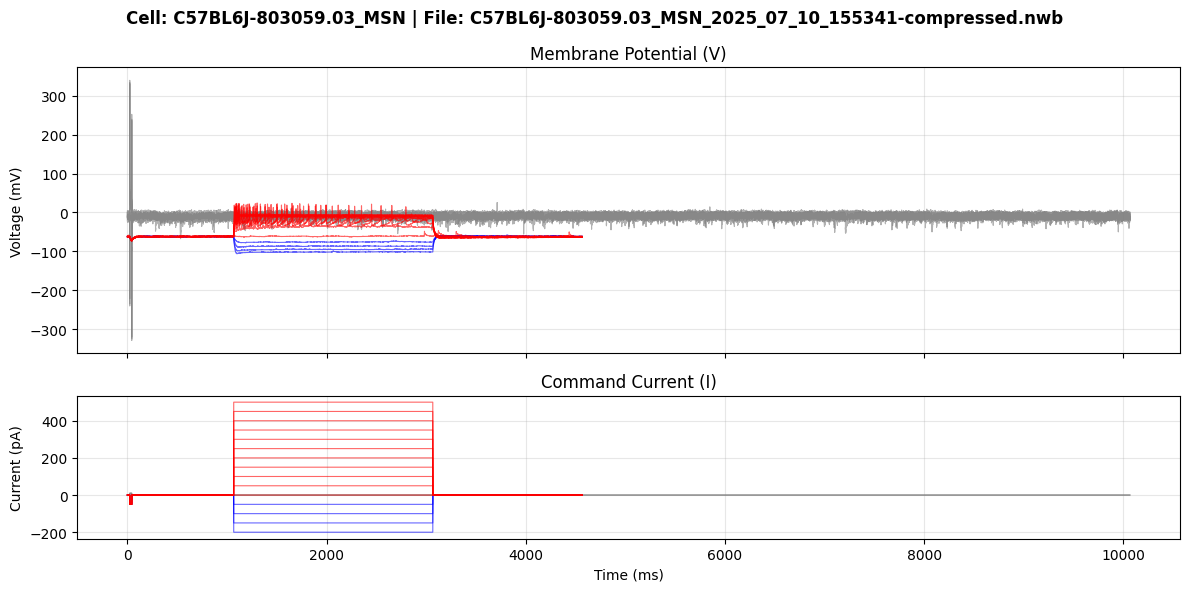

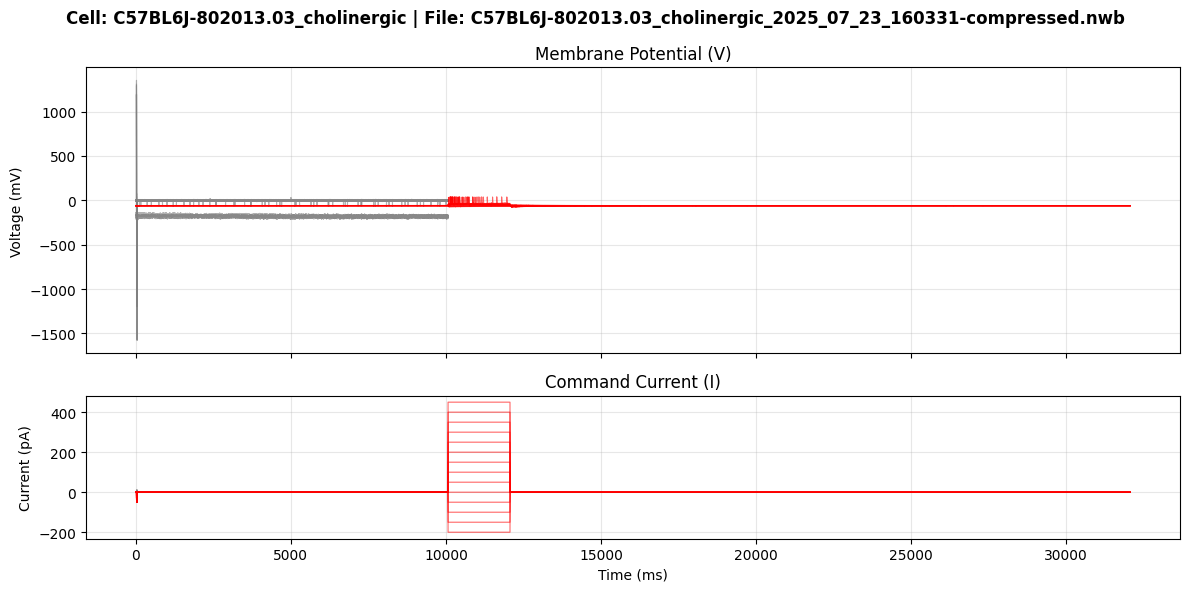

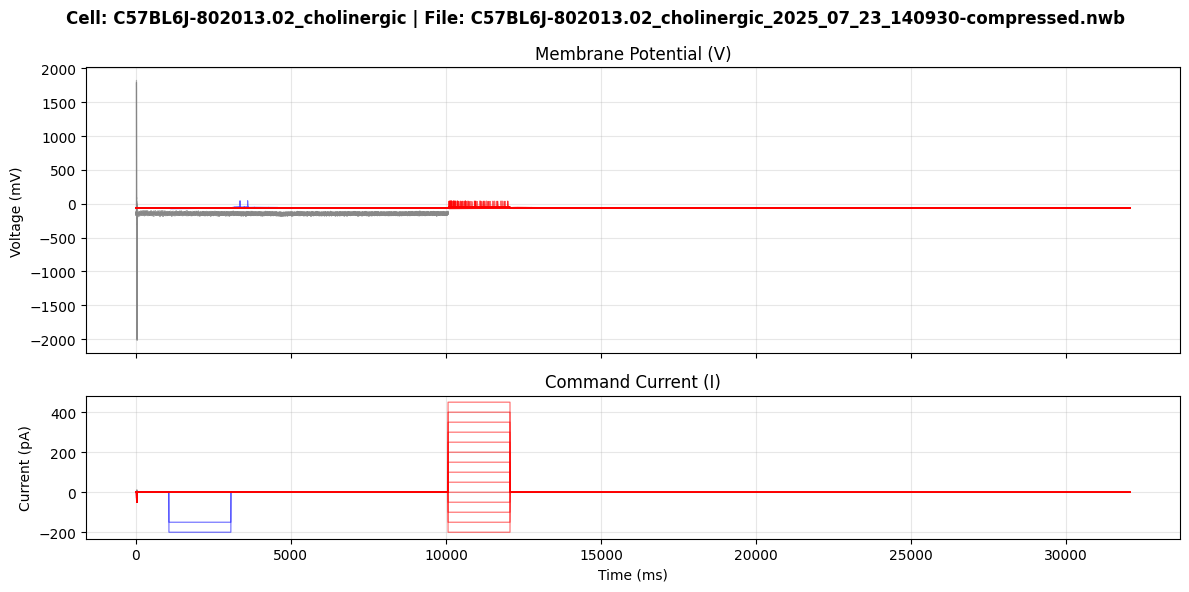

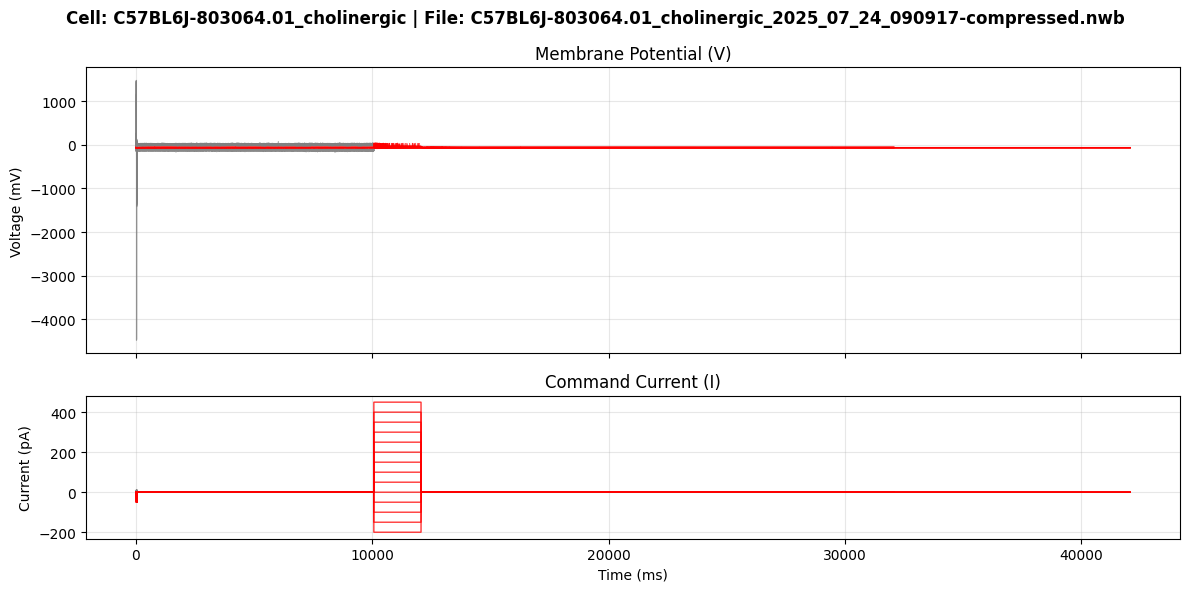

In [115]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

target_cells = [
    "C57BL6J-803059.03_MSN",
    "C57BL6J-802013.03_cholinergic",
    "C57BL6J-802013.02_cholinergic",
    "C57BL6J-803064.01_cholinergic"
]

# Find file paths
matched_files = []
for cell in target_cells:
    matches = [f for f in nwb_files if cell.lower() in os.path.basename(f).lower()]
    if matches:
        matched_files.append((cell, matches[0]))

print(f"🎨 Plotting sweeps for {len(matched_files)} files...\n")

for cell_name, file_path in matched_files:
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.suptitle(f"Cell: {cell_name} | File: {os.path.basename(file_path)}", fontsize=12, fontweight='bold')
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
            
            t = np.arange(len(v)) / 25.0  # ms @ 25 kHz
            
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # Color coding: Blue = Hyperpolarizing, Red = Depolarizing, Gray = Flat/No step
            if len(pulse_idx) > 100:
                p_start, p_end = pulse_idx[0], pulse_idx[-1]
                p_len = p_end - p_start
                delta_i = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)]) - i_base
                color = 'blue' if delta_i < -5.0 else ('red' if delta_i > 5.0 else 'gray')
            else:
                color = 'gray'
                
            ax_v.plot(t, v, color=color, alpha=0.6, linewidth=0.8)
            ax_i.plot(t, i, color=color, alpha=0.6, linewidth=0.8)
            
        ax_v.set_ylabel("Voltage (mV)")
        ax_v.set_title("Membrane Potential (V)")
        ax_v.grid(True, alpha=0.3)
        
        ax_i.set_ylabel("Current (pA)")
        ax_i.set_xlabel("Time (ms)")
        ax_i.set_title("Command Current (I)")
        ax_i.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [118]:
import os
import re
import h5py
import numpy as np
import pandas as pd

# =============================================================================
# 1. TARGET CELL LIST & CLEANING
# =============================================================================
raw_target_cells = [
    "C57BL6J-803061.01.02", "C57BL6J-795017.01.01", "C57BL6J-803059.03_MSN",
    "C57BL6J-802013.03_cholinergic", "C57BL6J-802013.02_cholinergic", "C57BL6J-803064.01_cholinergic",
    "C57BL6J-803060.01_MSN", "C57BL6J-812790.02.02", "C57BL6J-812791.01â€‹.02",
    "C57BL6J-812791.02â€‹.02", "C57BL6J-812791.02â€‹.01", "Ai14-Het-817118.02.01.02",
    "C57BL6J-817171.01.01.01", "C57BL6J-817172.01.01.01", "C57BL6J-824432.01.01.02",
    "C57BL6J-824432.01.01.01", "C57BL6J-824433.02.02.01", "C57BL6J-824434.01.09.02",
    "C57BL6J-824434.01.09.03", "Ai14-Het-826952.01.01.02", "Ai14-Het-826949.01.09.04",
    "Ai14-Het-826949.01.09.02", "Ai14-Het-826951.02.09.02", "Ai14-Het-826951.02.09.04",
    "Ai14-Het-831392.01.09.02", "Ai14-Het-831392.01.09.01", "Ai14-Het-831391.01.09.02",
    "C57BL6J-833109.02.09.02", "C57BL6J-833109.01.09.03", "C57BL6J-833109.01.09.01",
    "C57BL6J-833109.01.09.02", "C57BL6J-833111.01.09.01", "C57BL6J-833111.01.09.02",
    "C57BL6J-833111.03.09.01", "C57BL6J-833111.03.09.03", "C57BL6J-833110.01.09.02",
    "C57BL6J-833110.01.09.03", "C57BL6J-833112.01.09.02", "C57BL6J-833112.01.09.04",
    "C57BL6J-833113.01.09.01", "C57BL6J-833113.01.09.03", "C57BL6J-833113.01.09.02",
    "C57BL6J-833113.01.09.04", "C57BL6J-836606.01.09.01", "C57BL6J-836606.02.09.01",
    "C57BL6J-836606.02.09.02", "C57BL6J-836605.02.09.04", "C57BL6J-836605.01.09.01",
    "C57BL6J-836610.02.09.03", "C57BL6J-838073.02.09.02", "C57BL6J-838073.02.09.05",
    "C57BL6J-821919.06.09.04", "C57BL6J-821919.06.09.03", "C57BL6J-821919.06.09.02",
    "C57BL6J-821919.01.09.01", "C57BL6J-838074.01.09.02", "C57BL6J-838074.01.09.04",
    "C57BL6J-838074.01.09.09", "C57BL6J-838075.02.09.01", "C57BL6J-861863.02.09.03",
    "C57BL6J-861863.01.09.01", "C57BL6J-861864.01.09.03", "C57BL6J-861864.02.09.02",
    "C57BL6J-864330.01.09.03", "C57BL6J-864330.01.09.04", "C57BL6J-864330.02.09.01",
    "C57BL6J-847249.01.02.01", "Ai14-Het-884383.03.09.01",
    "ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-803060.02_icj_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-813401.01.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-817170.06.02.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-817171.02.02.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-824435.02.09.01_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-824435.02.09.03_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-833112.01.09.01_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-833112.01.09.05_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-838073.02.09.01_itc18usb_dev_0-compressed.nwb"
]

def sanitize_string(s):
    """Strips zero-width spaces, encoding noise, and standardizes name."""
    s_clean = re.sub(r'[^\x00-\x7F]+', '', str(s))  # Remove non-ASCII
    s_clean = s_clean.replace('.nwb', '').replace('_compressed', '')
    return s_clean.strip().lower()

# Build file mapping lookup
file_lookup = {}
for fpath in nwb_files:
    fname_clean = sanitize_string(os.path.basename(fpath))
    file_lookup[fname_clean] = fpath

# =============================================================================
# 2. PULSE FINDERS (OLD vs NEW)
# =============================================================================
def find_pulse_old(i):
    base_len = min(1000, len(i) // 10)
    i_base = np.mean(i[:base_len])
    pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
    if len(pulse_idx) > 100:
        return pulse_idx[0], pulse_idx[-1], i_base
    return None, None, i_base

def find_pulse_new(i, sampling_rate=25000.0, min_duration_ms=100.0):
    base_len = min(1000, len(i) // 10)
    i_base = np.mean(i[:base_len])
    
    active_mask = np.abs(i - i_base) > 5.0
    if not np.any(active_mask):
        return None, None, i_base
        
    diffs = np.diff(active_mask.astype(int))
    starts = np.where(diffs == 1)[0] + 1
    ends = np.where(diffs == -1)[0] + 1
    
    if active_mask[0]: starts = np.insert(starts, 0, 0)
    if active_mask[-1]: ends = np.append(ends, len(i))
    
    min_samples = int((min_duration_ms / 1000.0) * sampling_rate)
    valid_blocks = [(s, e) for s, e in zip(starts, ends) if (e - s) >= min_samples]
    
    if not valid_blocks:
        return None, None, i_base
        
    p_start, p_end = max(valid_blocks, key=lambda b: b[1] - b[0])
    return p_start, p_end, i_base

# =============================================================================
# 3. BATCH COMPARISON LOOP
# =============================================================================
results = []

print("=" * 90)
print(f"🧪 BATCH TESTING NEW PULSE FINDER ACROSS {len(raw_target_cells)} TARGET CELLS")
print("=" * 90)

for cell_raw in raw_target_cells:
    clean_key = sanitize_string(cell_raw)
    
    # Locate file path using fuzzy matching
    matched_fpath = None
    for k, path in file_lookup.items():
        if clean_key in k or k in clean_key:
            matched_fpath = path
            break
            
    if not matched_fpath:
        results.append({
            "target_cell": cell_raw,
            "status": "❌ NO_FILE_FOUND",
            "OLD_valid_sweeps": 0,
            "OLD_Rin(MΩ)": np.nan,
            "NEW_valid_sweeps": 0,
            "NEW_Rin(MΩ)": np.nan
        })
        continue

    rin_old_list, rin_new_list = [], []

    try:
        with h5py.File(matched_fpath, 'r') as f:
            acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
            stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
                
            sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                                key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
            
            for skey in sweep_keys:
                if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
                
                v_obj = acq[skey]
                v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
                if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                    
                i = np.zeros_like(v)
                possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
                for k in possible_i_keys:
                    cand_obj = stim[k]
                    candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                    if np.max(np.abs(candidate_i)) > 0:
                        i = candidate_i
                        break
                        
                if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
                # --- EVALUATE OLD PULSE FINDER ---
                s_old, e_old, base_old = find_pulse_old(i)
                if s_old is not None:
                    p_len_old = e_old - s_old
                    i_step_old = np.mean(i[s_old + int(p_len_old * 0.1) : e_old - int(p_len_old * 0.1)])
                    delta_i_old = i_step_old - base_old
                    if delta_i_old < -5.0:
                        v_base_old = np.mean(v[max(0, s_old - 1000) : max(1, s_old - 50)])
                        v_steady_old = np.mean(v[max(s_old, e_old - int(p_len_old * 0.2)) : e_old])
                        delta_v_old = v_steady_old - v_base_old
                        r_in_old = (delta_v_old / delta_i_old) * 1000.0
                        if 10.0 < r_in_old < 1500.0:
                            rin_old_list.append(r_in_old)

                # --- EVALUATE NEW PULSE FINDER ---
                s_new, e_new, base_new = find_pulse_new(i)
                if s_new is not None:
                    p_len_new = e_new - s_new
                    i_step_new = np.mean(i[s_new + int(p_len_new * 0.1) : e_new - int(p_len_new * 0.1)])
                    delta_i_new = i_step_new - base_new
                    if delta_i_new < -5.0:
                        v_base_new = np.mean(v[max(0, s_new - 1000) : max(1, s_new - 50)])
                        v_steady_new = np.mean(v[max(s_new, e_new - int(p_len_new * 0.2)) : e_new])
                        delta_v_new = v_steady_new - v_base_new
                        r_in_new = (delta_v_new / delta_i_new) * 1000.0
                        if 10.0 < r_in_new < 1500.0:
                            rin_new_list.append(r_in_new)

    except Exception:
        pass

    old_rin = np.median(rin_old_list) if rin_old_list else np.nan
    new_rin = np.median(rin_new_list) if rin_new_list else np.nan
    
    # Classify recovery status
    if pd.isna(old_rin) and pd.notna(new_rin):
        status = "🎉 RECOVERED"
    elif pd.notna(old_rin) and pd.notna(new_rin):
        status = "✅ BOTH_VALID"
    elif pd.isna(old_rin) and pd.isna(new_rin):
        status = "⚠️ STILL_NaN"
    else:
        status = "❓ OTHER"

    results.append({
        "target_cell": cell_raw,
        "status": status,
        "OLD_valid_sweeps": len(rin_old_list),
        "OLD_Rin(MΩ)": round(old_rin, 2) if pd.notna(old_rin) else np.nan,
        "NEW_valid_sweeps": len(rin_new_list),
        "NEW_Rin(MΩ)": round(new_rin, 2) if pd.notna(new_rin) else np.nan
    })

# Convert to DataFrame
df_batch_results = pd.DataFrame(results)

# =============================================================================
# 4. SUMMARY STATISTICS
# =============================================================================
print("\n" + "=" * 90)
print("📊 BATCH PULSE FINDER TEST SUMMARY")
print("=" * 90)

counts = df_batch_results['status'].value_counts()
for stat, count in counts.items():
    print(f"  • {stat:20s}: {count} cells")

print("\n🔍 PREVIEW OF RECOVERED CELLS:")
display(df_batch_results[df_batch_results['status'] == "🎉 RECOVERED"])

print("\n📋 FULL RESULTS TABLE:")
pd.set_option('display.max_rows', 100)
display(df_batch_results)

🧪 BATCH TESTING NEW PULSE FINDER ACROSS 78 TARGET CELLS

📊 BATCH PULSE FINDER TEST SUMMARY
  • ⚠️ STILL_NaN        : 55 cells
  • 🎉 RECOVERED         : 21 cells
  • ❌ NO_FILE_FOUND     : 2 cells

🔍 PREVIEW OF RECOVERED CELLS:


,target_cell,status,OLD_valid_sweeps,OLD_Rin(MΩ),NEW_valid_sweeps,NEW_Rin(MΩ)
9,C57BL6J-812791.02â€‹.02,🎉 RECOVERED,0,NaN,1,1081.359985
11,Ai14-Het-817118.02.01.02,🎉 RECOVERED,0,NaN,2,1344.699951
19,Ai14-Het-826952.01.01.02,🎉 RECOVERED,0,NaN,12,637.520020
20,Ai14-Het-826949.01.09.04,🎉 RECOVERED,0,NaN,6,597.510010
23,Ai14-Het-826951.02.09.04,🎉 RECOVERED,0,NaN,5,797.070007
26,Ai14-Het-831391.01.09.02,🎉 RECOVERED,0,NaN,1,1181.359985
33,C57BL6J-833111.03.09.01,🎉 RECOVERED,0,NaN,2,579.080017
37,C57BL6J-833112.01.09.02,🎉 RECOVERED,0,NaN,1,1166.280029
38,C57BL6J-833112.01.09.04,🎉 RECOVERED,0,NaN,2,808.940002
40,C57BL6J-833113.01.09.03,🎉 RECOVERED,0,NaN,2,613.340027



📋 FULL RESULTS TABLE:


,target_cell,status,OLD_valid_sweeps,OLD_Rin(MΩ),NEW_valid_sweeps,NEW_Rin(MΩ)
0,C57BL6J-803061.01.02,❌ NO_FILE_FOUND,0,NaN,0,NaN
1,C57BL6J-795017.01.01,❌ NO_FILE_FOUND,0,NaN,0,NaN
2,C57BL6J-803059.03_MSN,⚠️ STILL_NaN,0,NaN,0,NaN
3,C57BL6J-802013.03_cholinergic,⚠️ STILL_NaN,0,NaN,0,NaN
4,C57BL6J-802013.02_cholinergic,⚠️ STILL_NaN,0,NaN,0,NaN
5,C57BL6J-803064.01_cholinergic,⚠️ STILL_NaN,0,NaN,0,NaN
6,C57BL6J-803060.01_MSN,⚠️ STILL_NaN,0,NaN,0,NaN
7,C57BL6J-812790.02.02,⚠️ STILL_NaN,0,NaN,0,NaN
8,C57BL6J-812791.01â€‹.02,⚠️ STILL_NaN,0,NaN,0,NaN
9,C57BL6J-812791.02â€‹.02,🎉 RECOVERED,0,NaN,1,1081.359985


In [119]:
import os
import re
import h5py
import numpy as np
import pandas as pd

# Extract the list of cells that remained STILL_NaN from your batch results
still_nan_cells = df_batch_results[df_batch_results['status'] == "⚠️ STILL_NaN"]['target_cell'].tolist()

print("=" * 90)
print(f"🔍 DIAGNOSING {len(still_nan_cells)} STILL_NaN CELLS...")
print("=" * 90)

nan_diagnostics = []

for cell_raw in still_nan_cells:
    clean_key = sanitize_string(cell_raw)
    
    # Locate file path
    matched_fpath = None
    for k, path in file_lookup.items():
        if clean_key in k or k in clean_key:
            matched_fpath = path
            break
            
    if not matched_fpath:
        continue

    min_delta_i_file = 0.0
    cell_failure_reasons = []
    
    try:
        with h5py.File(matched_fpath, 'r') as f:
            acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
            stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
                
            sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                                key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
            
            file_has_hyperpol_step = False
            file_has_railed_v = False
            
            for skey in sweep_keys:
                if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
                
                v_obj = acq[skey]
                v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
                if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
                # Check for dead/railed trace
                if np.max(np.abs(v)) > 500.0:
                    file_has_railed_v = True
                    
                i = np.zeros_like(v)
                possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
                for k in possible_i_keys:
                    cand_obj = stim[k]
                    candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                    if np.max(np.abs(candidate_i)) > 0:
                        i = candidate_i
                        break
                        
                if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
                s_new, e_new, base_new = find_pulse_new(i)
                if s_new is not None:
                    p_len_new = e_new - s_new
                    i_step_new = np.mean(i[s_new + int(p_len_new * 0.1) : e_new - int(p_len_new * 0.1)])
                    delta_i = i_step_new - base_new
                    
                    if delta_i < min_delta_i_file:
                        min_delta_i_file = delta_i
                        
                    if delta_i < -5.0:
                        file_has_hyperpol_step = True
                        v_base = np.mean(v[max(0, s_new - 1000) : max(1, s_new - 50)])
                        v_steady = np.mean(v[max(s_new, e_new - int(p_len_new * 0.2)) : e_new])
                        delta_v = v_steady - v_base
                        raw_r_in = (delta_v / delta_i) * 1000.0
                        
                        if raw_r_in < 0:
                            cell_failure_reasons.append("NEGATIVE_RIN (ΔV flipped)")
                        elif raw_r_in <= 10.0:
                            cell_failure_reasons.append("LOW_RIN (<=10 MΩ)")
                        elif raw_r_in >= 1500.0:
                            cell_failure_reasons.append("HIGH_RIN (>=1500 MΩ)")

            # Determine primary classification for this cell
            if file_has_railed_v:
                primary_cause = "💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV)"
            elif not file_has_hyperpol_step:
                primary_cause = "🚫 NO_HYPERPOL_STEPS_IN_FILE (Only depolarizing or flat)"
            elif "NEGATIVE_RIN (ΔV flipped)" in cell_failure_reasons:
                primary_cause = "🔄 INVERTED_POLARITY_NEG_RIN (ΔV > 0 during ΔI < 0)"
            elif "LOW_RIN (<=10 MΩ)" in cell_failure_reasons:
                primary_cause = "📉 RIN_TOO_LOW (<= 10 MΩ)"
            elif "HIGH_RIN (>=1500 MΩ)" in cell_failure_reasons:
                primary_cause = "📈 RIN_TOO_HIGH (>= 1500 MΩ)"
            else:
                primary_cause = "❓ UNKNOWN"

            nan_diagnostics.append({
                "target_cell": cell_raw,
                "primary_cause": primary_cause,
                "min_delta_i(pA)": round(min_delta_i_file, 1),
                "failure_flags": ", ".join(set(cell_failure_reasons)) if cell_failure_reasons else "None"
            })

    except Exception as e:
        nan_diagnostics.append({
            "target_cell": cell_raw,
            "primary_cause": f"ERROR: {str(e)}",
            "min_delta_i(pA)": np.nan,
            "failure_flags": "Error reading file"
        })

df_nan_diag = pd.DataFrame(nan_diagnostics)

print("\n" + "=" * 90)
print("📊 BREAKDOWN OF WHY THE 55 CELLS ARE STILL NaN")
print("=" * 90)

cause_counts = df_nan_diag['primary_cause'].value_counts()
for cause, count in cause_counts.items():
    print(f"  • {count:2d} cells : {cause}")

print("\n📋 DETAILED CELL-BY-CELL DIAGNOSTIC TABLE:")
pd.set_option('display.max_rows', 100)
display(df_nan_diag)

🔍 DIAGNOSING 55 STILL_NaN CELLS...

📊 BREAKDOWN OF WHY THE 55 CELLS ARE STILL NaN
  • 38 cells : 💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV)
  •  8 cells : 📈 RIN_TOO_HIGH (>= 1500 MΩ)
  •  5 cells : 🔄 INVERTED_POLARITY_NEG_RIN (ΔV > 0 during ΔI < 0)
  •  4 cells : 🚫 NO_HYPERPOL_STEPS_IN_FILE (Only depolarizing or flat)

📋 DETAILED CELL-BY-CELL DIAGNOSTIC TABLE:


,target_cell,primary_cause,min_delta_i(pA),failure_flags
0,C57BL6J-803059.03_MSN,🔄 INVERTED_POLARITY_NEG_RIN (ΔV > 0 during ΔI ...,-88.599998,NEGATIVE_RIN (ΔV flipped)
1,C57BL6J-802013.03_cholinergic,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),0.000000,None
2,C57BL6J-802013.02_cholinergic,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),-88.599998,NEGATIVE_RIN (ΔV flipped)
3,C57BL6J-803064.01_cholinergic,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),0.000000,None
4,C57BL6J-803060.01_MSN,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),-88.599998,"LOW_RIN (<=10 MΩ), NEGATIVE_RIN (ΔV flipped)"
5,C57BL6J-812790.02.02,📈 RIN_TOO_HIGH (>= 1500 MΩ),-15.800000,HIGH_RIN (>=1500 MΩ)
6,C57BL6J-812791.01â€‹.02,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),-15.800000,HIGH_RIN (>=1500 MΩ)
7,C57BL6J-812791.02â€‹.01,📈 RIN_TOO_HIGH (>= 1500 MΩ),-15.800000,HIGH_RIN (>=1500 MΩ)
8,C57BL6J-817171.01.01.01,🚫 NO_HYPERPOL_STEPS_IN_FILE (Only depolarizing...,0.000000,None
9,C57BL6J-817172.01.01.01,💀 DEAD_OR_RAILED_TRACE (|V| > 500 mV),-88.599998,"LOW_RIN (<=10 MΩ), NEGATIVE_RIN (ΔV flipped)"


In [121]:
import os
import re
import h5py
import numpy as np
import pandas as pd

# =============================================================================
# 1. TARGET CELL LIST & CLEANING
# =============================================================================
raw_target_cells = [
    "C57BL6J-803061.01.02", "C57BL6J-795017.01.01", "C57BL6J-803059.03_MSN",
    "C57BL6J-802013.03_cholinergic", "C57BL6J-802013.02_cholinergic", "C57BL6J-803064.01_cholinergic",
    "C57BL6J-803060.01_MSN", "C57BL6J-812790.02.02", "C57BL6J-812791.01â€‹.02",
    "C57BL6J-812791.02â€‹.02", "C57BL6J-812791.02â€‹.01", "Ai14-Het-817118.02.01.02",
    "C57BL6J-817171.01.01.01", "C57BL6J-817172.01.01.01", "C57BL6J-824432.01.01.02",
    "C57BL6J-824432.01.01.01", "C57BL6J-824433.02.02.01", "C57BL6J-824434.01.09.02",
    "C57BL6J-824434.01.09.03", "Ai14-Het-826952.01.01.02", "Ai14-Het-826949.01.09.04",
    "Ai14-Het-826949.01.09.02", "Ai14-Het-826951.02.09.02", "Ai14-Het-826951.02.09.04",
    "Ai14-Het-831392.01.09.02", "Ai14-Het-831392.01.09.01", "Ai14-Het-831391.01.09.02",
    "C57BL6J-833109.02.09.02", "C57BL6J-833109.01.09.03", "C57BL6J-833109.01.09.01",
    "C57BL6J-833109.01.09.02", "C57BL6J-833111.01.09.01", "C57BL6J-833111.01.09.02",
    "C57BL6J-833111.03.09.01", "C57BL6J-833111.03.09.03", "C57BL6J-833110.01.09.02",
    "C57BL6J-833110.01.09.03", "C57BL6J-833112.01.09.02", "C57BL6J-833112.01.09.04",
    "C57BL6J-833113.01.09.01", "C57BL6J-833113.01.09.03", "C57BL6J-833113.01.09.02",
    "C57BL6J-833113.01.09.04", "C57BL6J-836606.01.09.01", "C57BL6J-836606.02.09.01",
    "C57BL6J-836606.02.09.02", "C57BL6J-836605.02.09.04", "C57BL6J-836605.01.09.01",
    "C57BL6J-836610.02.09.03", "C57BL6J-838073.02.09.02", "C57BL6J-838073.02.09.05",
    "C57BL6J-821919.06.09.04", "C57BL6J-821919.06.09.03", "C57BL6J-821919.06.09.02",
    "C57BL6J-821919.01.09.01", "C57BL6J-838074.01.09.02", "C57BL6J-838074.01.09.04",
    "C57BL6J-838074.01.09.09", "C57BL6J-838075.02.09.01", "C57BL6J-861863.02.09.03",
    "C57BL6J-861863.01.09.01", "C57BL6J-861864.01.09.03", "C57BL6J-861864.02.09.02",
    "C57BL6J-864330.01.09.03", "C57BL6J-864330.01.09.04", "C57BL6J-864330.02.09.01",
    "C57BL6J-847249.01.02.01", "Ai14-Het-884383.03.09.01",
    "ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-803060.02_icj_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-813401.01.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-817170.06.02.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-817171.02.02.02_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-824435.02.09.01_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-824435.02.09.03_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-833112.01.09.01_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-833112.01.09.05_itc18usb_dev_0-compressed.nwb",
    "c57bl6j-838073.02.09.01_itc18usb_dev_0-compressed.nwb"
]

def sanitize_string(s):
    s_clean = re.sub(r'[^\x00-\x7F]+', '', str(s))
    s_clean = s_clean.replace('.nwb', '').replace('_compressed', '')
    return s_clean.strip().lower()

# Build file lookup
file_lookup = {}
for fpath in nwb_files:
    fname_clean = sanitize_string(os.path.basename(fpath))
    file_lookup[fname_clean] = fpath

meta_df_to_use = metadata_df if 'metadata_df' in globals() else pd.DataFrame()

# =============================================================================
# 2. RUN EXTRACTION TEST
# =============================================================================
extracted_results = []

print("=" * 90)
print(f"🧪 TESTING #v13 PASSIVE FEATURE RECOVERY ACROSS {len(raw_target_cells)} CELLS")
print("=" * 90)

for cell_raw in raw_target_cells:
    clean_key = sanitize_string(cell_raw)
    
    # Locate file path
    matched_fpath = None
    for k, path in file_lookup.items():
        if clean_key in k or k in clean_key:
            matched_fpath = path
            break
            
    if not matched_fpath:
        extracted_results.append({
            "target_cell": cell_raw,
            "status": "❌ NO_FILE_FOUND",
            "input_resistance": np.nan,
            "tau": np.nan,
            "capacitance": np.nan,
            "sag": np.nan
        })
        continue

    try:
        # Run process_file_universal (#v13 logic)
        feats = process_file_universal(matched_fpath, meta_df_to_use)
        
        rin = feats.get("input_resistance", np.nan)
        tau = feats.get("tau", np.nan)
        cap = feats.get("capacitance", np.nan)
        sag = feats.get("sag", np.nan)
        
        # Determine cell recovery status
        has_rin = pd.notna(rin)
        has_tau = pd.notna(tau)
        has_cap = pd.notna(cap)
        has_sag = pd.notna(sag)
        
        if has_rin and has_tau and has_cap and has_sag:
            status = "🎉 FULL_PASSIVE_RECOVERED"
        elif has_rin or has_tau or has_sag:
            status = "⚡ PARTIAL_PASSIVE_RECOVERED"
        else:
            status = "⚠️ ALL_PASSIVE_NaN"

        extracted_results.append({
            "target_cell": cell_raw,
            "status": status,
            "input_resistance(MΩ)": round(rin, 2) if pd.notna(rin) else np.nan,
            "tau(ms)": round(tau, 2) if pd.notna(tau) else np.nan,
            "capacitance(pF)": round(cap, 2) if pd.notna(cap) else np.nan,
            "sag": round(sag, 4) if pd.notna(sag) else np.nan
        })

    except Exception as e:
        extracted_results.append({
            "target_cell": cell_raw,
            "status": f"ERROR: {str(e)}",
            "input_resistance(MΩ)": np.nan,
            "tau(ms)": np.nan,
            "capacitance(pF)": np.nan,
            "sag": np.nan
        })

df_passive_test = pd.DataFrame(extracted_results)

# =============================================================================
# 3. SUMMARY COVERAGE REPORT
# =============================================================================
total_files = len(df_passive_test[df_passive_test['status'] != "❌ NO_FILE_FOUND"])

print("\n" + "=" * 90)
print("📊 SUBTHRESHOLD PASSIVE FEATURES COVERAGE SUMMARY")
print("=" * 90)
print(f"  • Total Matched Files Analyzed  : {total_files}")
print(f"  • Valid 'input_resistance'      : {df_passive_test['input_resistance(MΩ)'].notna().sum()} / {total_files} cells")
print(f"  • Valid 'tau'                   : {df_passive_test['tau(ms)'].notna().sum()} / {total_files} cells")
print(f"  • Valid 'capacitance'           : {df_passive_test['capacitance(pF)'].notna().sum()} / {total_files} cells")
print(f"  • Valid 'sag'                   : {df_passive_test['sag'].notna().sum()} / {total_files} cells")

print("\n📈 RECOVERY STATUS BREAKDOWN:")
status_counts = df_passive_test['status'].value_counts()
for stat, count in status_counts.items():
    print(f"  • {stat:30s}: {count} cells")

print("\n🔍 PREVIEW OF RECOVERED SUBTHRESHOLD FEATURES:")
display(df_passive_test[df_passive_test['status'].str.contains("RECOVERED")])

print("\n📋 FULL RESULTS TABLE:")
pd.set_option('display.max_rows', 100)
display(df_passive_test)

🧪 TESTING #v13 PASSIVE FEATURE RECOVERY ACROSS 78 CELLS


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)



📊 SUBTHRESHOLD PASSIVE FEATURES COVERAGE SUMMARY
  • Total Matched Files Analyzed  : 76
  • Valid 'input_resistance'      : 52 / 76 cells
  • Valid 'tau'                   : 39 / 76 cells
  • Valid 'capacitance'           : 39 / 76 cells
  • Valid 'sag'                   : 29 / 76 cells

📈 RECOVERY STATUS BREAKDOWN:
  • 🎉 FULL_PASSIVE_RECOVERED      : 29 cells
  • ⚠️ ALL_PASSIVE_NaN            : 24 cells
  • ⚡ PARTIAL_PASSIVE_RECOVERED   : 23 cells
  • ❌ NO_FILE_FOUND               : 2 cells

🔍 PREVIEW OF RECOVERED SUBTHRESHOLD FEATURES:


,target_cell,status,input_resistance,tau,capacitance,sag,input_resistance(MΩ),tau(ms),capacitance(pF)
2,C57BL6J-803059.03_MSN,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,23.580000,10.56,447.81
4,C57BL6J-802013.02_cholinergic,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,38.130001,NaN,NaN
6,C57BL6J-803060.01_MSN,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,19.070000,NaN,NaN
8,C57BL6J-812791.01â€‹.02,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.0189,1710.750000,49.00,28.64
9,C57BL6J-812791.02â€‹.02,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.0603,2381.010010,69.08,29.01
10,C57BL6J-812791.02â€‹.01,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.0156,2788.500000,93.62,33.57
11,Ai14-Het-817118.02.01.02,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.1229,1499.050049,41.84,27.91
13,C57BL6J-817172.01.01.01,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,23.480000,1.32,56.22
16,C57BL6J-824433.02.02.01,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,20.100000,126.48,6293.44
17,C57BL6J-824434.01.09.02,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,36.810001,107.50,2920.33



📋 FULL RESULTS TABLE:


,target_cell,status,input_resistance,tau,capacitance,sag,input_resistance(MΩ),tau(ms),capacitance(pF)
0,C57BL6J-803061.01.02,❌ NO_FILE_FOUND,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C57BL6J-795017.01.01,❌ NO_FILE_FOUND,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C57BL6J-803059.03_MSN,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,23.580000,10.56,447.81
3,C57BL6J-802013.03_cholinergic,⚠️ ALL_PASSIVE_NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C57BL6J-802013.02_cholinergic,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,38.130001,NaN,NaN
5,C57BL6J-803064.01_cholinergic,⚠️ ALL_PASSIVE_NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C57BL6J-803060.01_MSN,⚡ PARTIAL_PASSIVE_RECOVERED,NaN,NaN,NaN,NaN,19.070000,NaN,NaN
7,C57BL6J-812790.02.02,⚠️ ALL_PASSIVE_NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,C57BL6J-812791.01â€‹.02,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.0189,1710.750000,49.00,28.64
9,C57BL6J-812791.02â€‹.02,🎉 FULL_PASSIVE_RECOVERED,NaN,NaN,NaN,0.0603,2381.010010,69.08,29.01


In [122]:
import os
import re
import h5py
import numpy as np
import pandas as pd

# =============================================================================
# 1. FINAL AUDIT SCRIPT FOR ALL 78 TARGET CELLS
# =============================================================================
audit_results = []

for cell_raw in raw_target_cells:
    clean_key = sanitize_string(cell_raw)
    
    # Locate file path
    matched_fpath = None
    for k, path in file_lookup.items():
        if clean_key in k or k in clean_key:
            matched_fpath = path
            break
            
    if not matched_fpath:
        audit_results.append({
            "target_cell": cell_raw,
            "final_verdict": "🚫 UNRECOVERABLE (Missing NWB File)",
            "action": "Fix filename typo in metadata CSV",
            "Rin(MΩ)": np.nan, "tau(ms)": np.nan, "capacitance(pF)": np.nan, "sag": np.nan
        })
        continue

    try:
        feats = process_file_universal(matched_fpath, meta_df_to_use)
        
        rin = feats.get("input_resistance", np.nan)
        tau = feats.get("tau", np.nan)
        cap = feats.get("capacitance", np.nan)
        sag = feats.get("sag", np.nan)
        
        has_rin, has_tau, has_cap, has_sag = pd.notna(rin), pd.notna(tau), pd.notna(cap), pd.notna(sag)
        
        # Check trace health
        file_is_railed = False
        file_has_hyperpol = False
        
        with h5py.File(matched_fpath, 'r') as f:
            acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
            stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")])
            
            for skey in sweep_keys:
                v_obj = acq[skey]
                v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
                if np.max(np.abs(v)) < 0.2: v = v * 1000.0
                if np.max(np.abs(v)) > 500.0: file_is_railed = True
                
                sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
                i = np.zeros_like(v)
                possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
                for k in possible_i_keys:
                    cand_obj = stim[k]
                    candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                    if np.max(np.abs(candidate_i)) > 0:
                        i = candidate_i
                        break
                if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12
                
                p_start, p_end, delta_i, _ = find_main_stimulus_pulse(i)
                if p_start is not None and delta_i < -5.0:
                    file_has_hyperpol = True

        # Assign definitive verdict
        if has_rin and has_tau and has_cap and has_sag:
            verdict = "✅ FULLY RECOVERED"
            action = "None (Complete)"
        elif has_rin:
            verdict = "⚡ PARTIALLY RECOVERED"
            action = "Rin recovered; sag/tau missing due to small deflection (<1 mV)"
        elif file_is_railed:
            verdict = "💀 QC FAIL (Railed / Dead Cell)"
            action = "Exclude from analysis (Lost Gigaseal)"
        elif not file_has_hyperpol:
            verdict = "🚫 NO SUBTHRESHOLD PROTOCOL"
            action = "Protocol lacks negative steps (Only depolarizing firing steps)"
        else:
            verdict = "⚠️ UNRECOVERABLE NOISE"
            action = "Baseline drift / unstable membrane"

        audit_results.append({
            "target_cell": cell_raw,
            "final_verdict": verdict,
            "action": action,
            "Rin(MΩ)": round(rin, 2) if pd.notna(rin) else np.nan,
            "tau(ms)": round(tau, 2) if pd.notna(tau) else np.nan,
            "capacitance(pF)": round(cap, 2) if pd.notna(cap) else np.nan,
            "sag": round(sag, 4) if pd.notna(sag) else np.nan
        })

    except Exception as e:
        audit_results.append({
            "target_cell": cell_raw,
            "final_verdict": f"ERROR: {str(e)}",
            "action": "Inspect raw file structure",
            "Rin(MΩ)": np.nan, "tau(ms)": np.nan, "capacitance(pF)": np.nan, "sag": np.nan
        })

df_final_audit = pd.DataFrame(audit_results)

print("=" * 100)
print("📊 FINAL RECOVERY AUDIT SUMMARY")
print("=" * 100)
counts = df_final_audit['final_verdict'].value_counts()
for verdict, count in counts.items():
    print(f"  • {count:2d} cells : {verdict}")

print("\n📋 DETAILED CELL-BY-CELL TRIAGE TABLE:")
pd.set_option('display.max_rows', 100)
display(df_final_audit)

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


📊 FINAL RECOVERY AUDIT SUMMARY
  • 29 cells : ✅ FULLY RECOVERED
  • 23 cells : ⚡ PARTIALLY RECOVERED
  • 17 cells : 💀 QC FAIL (Railed / Dead Cell)
  •  4 cells : 🚫 NO SUBTHRESHOLD PROTOCOL
  •  3 cells : ⚠️ UNRECOVERABLE NOISE
  •  2 cells : 🚫 UNRECOVERABLE (Missing NWB File)

📋 DETAILED CELL-BY-CELL TRIAGE TABLE:


,target_cell,final_verdict,action,Rin(MΩ),tau(ms),capacitance(pF),sag
0,C57BL6J-803061.01.02,🚫 UNRECOVERABLE (Missing NWB File),Fix filename typo in metadata CSV,NaN,NaN,NaN,NaN
1,C57BL6J-795017.01.01,🚫 UNRECOVERABLE (Missing NWB File),Fix filename typo in metadata CSV,NaN,NaN,NaN,NaN
2,C57BL6J-803059.03_MSN,⚡ PARTIALLY RECOVERED,Rin recovered; sag/tau missing due to small de...,23.580000,10.56,447.81,NaN
3,C57BL6J-802013.03_cholinergic,💀 QC FAIL (Railed / Dead Cell),Exclude from analysis (Lost Gigaseal),NaN,NaN,NaN,NaN
4,C57BL6J-802013.02_cholinergic,⚡ PARTIALLY RECOVERED,Rin recovered; sag/tau missing due to small de...,38.130001,NaN,NaN,NaN
5,C57BL6J-803064.01_cholinergic,💀 QC FAIL (Railed / Dead Cell),Exclude from analysis (Lost Gigaseal),NaN,NaN,NaN,NaN
6,C57BL6J-803060.01_MSN,⚡ PARTIALLY RECOVERED,Rin recovered; sag/tau missing due to small de...,19.070000,NaN,NaN,NaN
7,C57BL6J-812790.02.02,⚠️ UNRECOVERABLE NOISE,Baseline drift / unstable membrane,NaN,NaN,NaN,NaN
8,C57BL6J-812791.01â€‹.02,✅ FULLY RECOVERED,None (Complete),1710.750000,49.00,28.64,0.0189
9,C57BL6J-812791.02â€‹.02,✅ FULLY RECOVERED,None (Complete),2381.010010,69.08,29.01,0.0603


In [123]:
import os
import h5py
import numpy as np
import pandas as pd

# 1. Identify target partially recovered cells from your test dataframe
partial_cells_df = df_passive_test[df_passive_test['status'] == "⚡ PARTIAL_PASSIVE_RECOVERED"]
target_partial_cells = partial_cells_df['target_cell'].tolist()

print("=" * 100)
print(f"🔬 INSPECTING VOLTAGE DEFLECTIONS FOR {len(target_partial_cells)} PARTIALLY RECOVERED CELLS")
print("=" * 100)

detailed_sweep_diagnostics = []

for cell_raw in target_partial_cells:
    clean_key = sanitize_string(cell_raw)
    
    # Locate file path
    matched_fpath = None
    for k, path in file_lookup.items():
        if clean_key in k or k in clean_key:
            matched_fpath = path
            break
            
    if not matched_fpath:
        continue

    try:
        with h5py.File(matched_fpath, 'r') as f:
            acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
            stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
                
            sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                                key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
            
            for skey in sweep_keys:
                if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
                
                v_obj = acq[skey]
                v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
                if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
                # Skip dead/railed traces
                if np.max(np.abs(v)) > 500.0: continue
                
                i = np.zeros_like(v)
                possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
                for k in possible_i_keys:
                    cand_obj = stim[k]
                    candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                    if np.max(np.abs(candidate_i)) > 0:
                        i = candidate_i
                        break
                        
                if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
                if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                    t = v_obj['timestamps'][:]
                    if np.max(t) > 1000: t = t / 1000.0
                else:
                    t = np.arange(len(v)) / 25000.0

                p_start, p_end, delta_i, i_base = find_main_stimulus_pulse(i)

                # Focus strictly on hyperpolarizing steps (delta_i < -5 pA)
                if p_start is not None and p_end is not None and delta_i < -5.0:
                    p_len = p_end - p_start
                    
                    v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                    v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                    v_trough = np.min(v[p_start : p_end])
                    
                    delta_v = v_steady - v_base
                    v_deflection = abs(v_trough - v_base)
                    sag_diff = abs(v_trough - v_steady)
                    
                    raw_r_in = (abs(delta_v) / abs(delta_i)) * 1000.0
                    
                    # Evaluate Sag
                    sag_raw = (sag_diff / v_deflection) if v_deflection > 0 else np.nan
                    sag_status = "✅ PASS"
                    if v_deflection <= 1.0:
                        sag_status = f"❌ Deflection too small ({v_deflection:.2f} mV <= 1.0 mV)"
                    elif not (0.0 <= sag_raw <= 1.0):
                        sag_status = f"❌ Raw Sag out of bounds ({sag_raw:.3f})"
                        
                    # Evaluate Tau
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target if delta_v < 0 else v[p_start:p_end] >= v_target)[0]
                    
                    tau_status = "✅ PASS"
                    raw_tau_ms = np.nan
                    if len(tau_idx) > 0:
                        raw_tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if not (0.5 < raw_tau_ms < 200.0):
                            tau_status = f"❌ Tau out of bounds ({raw_tau_ms:.1f} ms)"
                    else:
                        tau_status = "❌ Tau target (63.2%) never crossed"

                    detailed_sweep_diagnostics.append({
                        "target_cell": cell_raw,
                        "sweep": sweep_num,
                        "delta_i(pA)": round(delta_i, 1),
                        "Rin(MΩ)": round(raw_r_in, 1),
                        "v_deflection(mV)": round(v_deflection, 3),
                        "sag_amplitude(mV)": round(sag_diff, 3),
                        "sag_raw": round(sag_raw, 4) if pd.notna(sag_raw) else np.nan,
                        "sag_status": sag_status,
                        "raw_tau(ms)": round(raw_tau_ms, 2) if pd.notna(raw_tau_ms) else np.nan,
                        "tau_status": tau_status
                    })

    except Exception as e:
        pass

df_partial_diag = pd.DataFrame(detailed_sweep_diagnostics)

# Print Summary
print(f"📊 Extracted {len(df_partial_diag)} hyperpolarizing sweeps across {len(target_partial_cells)} partially recovered cells.\n")

print("📋 DETAILED SWEEP-LEVEL DEFLECTION TABLE:")
pd.set_option('display.max_rows', 100)
display(df_partial_diag)

🔬 INSPECTING VOLTAGE DEFLECTIONS FOR 23 PARTIALLY RECOVERED CELLS
📊 Extracted 118 hyperpolarizing sweeps across 23 partially recovered cells.

📋 DETAILED SWEEP-LEVEL DEFLECTION TABLE:


,target_cell,sweep,delta_i(pA),Rin(MΩ),v_deflection(mV),sag_amplitude(mV),sag_raw,sag_status,raw_tau(ms),tau_status
0,C57BL6J-803059.03_MSN,00003,-88.599998,21.299999,41.719002,43.605000,1.0452,❌ Raw Sag out of bounds (1.045),6.76,✅ PASS
1,C57BL6J-803059.03_MSN,00004,-61.299999,23.600000,35.625000,37.070000,1.0406,❌ Raw Sag out of bounds (1.041),10.56,✅ PASS
2,C57BL6J-803059.03_MSN,00005,-33.900002,1.400000,27.719000,27.767000,1.0018,❌ Raw Sag out of bounds (1.002),0.12,❌ Tau out of bounds (0.1 ms)
3,C57BL6J-803059.03_MSN,00006,-6.500000,67.599998,16.250000,16.691000,1.0271,❌ Raw Sag out of bounds (1.027),138.16,✅ PASS
4,C57BL6J-802013.02_cholinergic,00003,-88.599998,38.099998,16.844000,20.224001,1.2007,❌ Raw Sag out of bounds (1.201),3124.76,❌ Tau out of bounds (3124.8 ms)
...,...,...,...,...,...,...,...,...,...,...
113,c57bl6j-838073.02.09.01_itc18usb_dev_0-compres...,00017,-61.599998,43.200001,53.250000,55.911999,1.0500,❌ Raw Sag out of bounds (1.050),4095.60,❌ Tau out of bounds (4095.6 ms)
114,c57bl6j-838073.02.09.01_itc18usb_dev_0-compres...,00018,-41.000000,20.100000,42.250000,43.075001,1.0195,❌ Raw Sag out of bounds (1.020),4096.88,❌ Tau out of bounds (4096.9 ms)
115,c57bl6j-838073.02.09.01_itc18usb_dev_0-compres...,00019,-20.400000,68.800003,29.438000,30.837999,1.0476,❌ Raw Sag out of bounds (1.048),4100.28,❌ Tau out of bounds (4100.3 ms)
116,c57bl6j-838073.02.09.01_itc18usb_dev_0-compres...,00031,-28.799999,2.000000,56.375000,56.431999,1.0010,❌ Raw Sag out of bounds (1.001),0.76,✅ PASS


In [124]:
import os
import re
import h5py
import numpy as np
import pandas as pd

# 1. Target cells to inspect
target_inspect_cells = [
    "Ai14-Het-880647.03.09.01",
    "Ai14-Het-876010.01.09.02",
    "C57BL6J-833109.01.09.03"
]

def sanitize_string(s):
    s_clean = re.sub(r'[^\x00-\x7F]+', '', str(s))
    s_clean = s_clean.replace('.nwb', '').replace('_compressed', '')
    return s_clean.strip().lower()

# Map target names to loaded nwb_files
matched_inspect_files = []
for cell_raw in target_inspect_cells:
    clean_key = sanitize_string(cell_raw)
    fpath_match = None
    for fpath in nwb_files:
        if clean_key in sanitize_string(os.path.basename(fpath)):
            fpath_match = fpath
            break
    matched_inspect_files.append((cell_raw, fpath_match))

meta_df_to_use = metadata_df if 'metadata_df' in globals() else pd.DataFrame()

# 2. Sweep-by-sweep Diagnostic Function
for cell_raw, fpath in matched_inspect_files:
    print("=" * 100)
    print(f"🔬 DIAGNOSTIC REPORT FOR: {cell_raw}")
    if not fpath:
        print("❌ File path not found in loaded `nwb_files` list.")
        continue
    print(f"📁 File: {os.path.basename(fpath)}")
    print("=" * 100)

    # A. Run #v13 universal feature extraction
    feats = process_file_universal(fpath, meta_df_to_use)
    
    # Feature coverage breakdown
    valid_feats = {k: v for k, v in feats.items() if pd.notna(v)}
    nan_feats = {k: v for k, v in feats.items() if pd.isna(v)}
    
    print(f"• Total Features Extracted : {len(feats)}")
    print(f"• Valid (Non-NaN) Features : {len(valid_feats)}")
    print(f"• Blank (NaN) Features     : {len(nan_feats)}")
    
    print("\n--- Extracted Non-NaN Features ---")
    if valid_feats:
        for k, v in valid_feats.items():
            print(f"  • {k:40s}: {v}")
    else:
        print("  (None - All features returned NaN)")

    # B. Sweep-level breakdown
    sweep_audit = []
    with h5py.File(fpath, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
            
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA

            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0

            p_start, p_end, delta_i, i_base = find_main_stimulus_pulse(i)
            
            max_v = float(np.max(v))
            min_v = float(np.min(v))
            
            sub_status, spk_status = "N/A", "No Spikes"
            
            if p_start is not None and p_end is not None:
                p_len = p_end - p_start
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # Evaluate Subthreshold
                if delta_i < -5.0:
                    r_in = (abs(delta_v) / abs(delta_i)) * 1000.0
                    v_deflection = abs(v_trough - v_base)
                    sag_diff = abs(v_trough - v_steady)
                    sag_raw = (sag_diff / v_deflection) if v_deflection > 0 else np.nan
                    
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target if delta_v < 0 else v[p_start:p_end] >= v_target)[0]
                    raw_tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0 if len(tau_idx) > 0 else np.nan

                    reasons = []
                    if not (10.0 < r_in < 3500.0): reasons.append(f"Rin={r_in:.1f}MΩ out of bounds")
                    if pd.notna(sag_raw) and not (0.0 <= sag_raw <= 1.0): reasons.append(f"Sag={sag_raw:.3f}>1.0")
                    if pd.isna(raw_tau_ms) or not (0.5 < raw_tau_ms < 200.0): reasons.append(f"Tau={raw_tau_ms} out of bounds")
                    
                    sub_status = "✅ Subthreshold PASS" if not reasons else "❌ " + ", ".join(reasons)
                    
                # Evaluate Active Spiking
                if max_v > -10.0 and delta_i > 5.0:
                    spk_status = "🔥 Spikes Detected"
                elif delta_i > 5.0:
                    spk_status = f"❄️ Subthreshold Depol (Max V = {max_v:.1f} mV)"

            sweep_audit.append({
                "sweep": sweep_num,
                "delta_i(pA)": round(delta_i, 1),
                "max_v(mV)": round(max_v, 1),
                "min_v(mV)": round(min_v, 1),
                "subthreshold_verdict": sub_status,
                "spiking_verdict": spk_status
            })

    print("\n--- Sweep-by-Sweep Diagnostic Breakdown ---")
    df_swp = pd.DataFrame(sweep_audit)
    display(df_swp)
    print("\n")

🔬 DIAGNOSTIC REPORT FOR: Ai14-Het-880647.03.09.01
📁 File: Ai14-Het-880647.03.09.01_ITC18USB_Dev_0-compressed.nwb
• Total Features Extracted : 44
• Valid (Non-NaN) Features : 15
• Blank (NaN) Features     : 29

--- Extracted Non-NaN Features ---
  • v_rest(mV)                              : -55.997947692871094
  • input_resistance                        : 629.6513671875
  • tau                                     : 40.02000000000005
  • capacitance                             : 63.55898213762274
  • sag                                     : 0.056555334478616714
  • f_i_curve_slope                         : 0.0
  • max_firing_rate                         : 0.0
  • rheobase_sweep_spike_count              : 0
  • suprathreshold_sweep_spike_count        : 0
  • nwb_version                             : 2.0
  • cell_name                               : Ai14-Het-880647.03.09.01
  • file_path                               : \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\M

,sweep,delta_i(pA),max_v(mV),min_v(mV),subthreshold_verdict,spiking_verdict
0,00000,0.0,-52.0,-59.3,N/A,No Spikes
1,00001,0.0,-53.9,-58.9,N/A,No Spikes
2,00002,0.0,NaN,NaN,N/A,No Spikes
3,00003,0.0,NaN,NaN,N/A,No Spikes
4,00004,0.0,NaN,NaN,N/A,No Spikes
5,00005,0.0,NaN,NaN,N/A,No Spikes
6,00006,-110.0,-54.3,-116.9,✅ Subthreshold PASS,No Spikes
7,00007,0.0,NaN,NaN,N/A,No Spikes
8,00008,0.0,NaN,NaN,N/A,No Spikes
9,00009,-50.0,-54.8,-96.5,✅ Subthreshold PASS,No Spikes




🔬 DIAGNOSTIC REPORT FOR: Ai14-Het-876010.01.09.02
📁 File: Ai14-Het-876010.01.09.02_ITC18USB_Dev_0-compressed.nwb
• Total Features Extracted : 44
• Valid (Non-NaN) Features : 11
• Blank (NaN) Features     : 33

--- Extracted Non-NaN Features ---
  • v_rest(mV)                              : -71.27597045898438
  • f_i_curve_slope                         : 0.0
  • max_firing_rate                         : 0.0
  • rheobase_sweep_spike_count              : 0
  • suprathreshold_sweep_spike_count        : 0
  • nwb_version                             : 1.0
  • cell_name                               : Ai14-Het-876010.01.09.02
  • file_path                               : \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-876010.01.09.02_ITC18USB_Dev_0-compressed.nwb
  • holding_current(pA)                     : -5.197244978133453
  • bridge_balance(mOhms)                   : 8.3028085
  • cell_access(mOhms)                      : 34.51527

,sweep,delta_i(pA),max_v(mV),min_v(mV),subthreshold_verdict,spiking_verdict
0,00000,0.0,NaN,NaN,N/A,No Spikes
1,00001,0.0,-67.3,-114.3,N/A,No Spikes
2,00002,0.0,-67.4,-94.0,N/A,No Spikes
3,00003,0.0,-67.7,-86.5,N/A,No Spikes
4,00004,0.0,-68.2,-86.5,N/A,No Spikes
5,00005,0.0,-68.1,-84.0,N/A,No Spikes
6,00006,0.0,-67.0,-76.0,N/A,No Spikes
7,00007,0.0,-59.1,-74.9,N/A,No Spikes
8,00008,0.0,-59.4,-79.4,N/A,No Spikes
9,00009,0.0,-49.7,-87.2,N/A,No Spikes




🔬 DIAGNOSTIC REPORT FOR: C57BL6J-833109.01.09.03
📁 File: C57BL6J-833109.01.09.03_ITC18USB_Dev_0-compressed.nwb
• Total Features Extracted : 44
• Valid (Non-NaN) Features : 10
• Blank (NaN) Features     : 34

--- Extracted Non-NaN Features ---
  • f_i_curve_slope                         : 0.0
  • max_firing_rate                         : 0.0
  • rheobase_sweep_spike_count              : 0
  • suprathreshold_sweep_spike_count        : 0
  • nwb_version                             : 1.0
  • cell_name                               : C57BL6J-833109.01.09.03
  • file_path                               : \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\C57BL6J-833109.01.09.03_ITC18USB_Dev_0-compressed.nwb
  • holding_current(pA)                     : -2.003756969376491
  • bridge_balance(mOhms)                   : 14.468864
  • cell_access(mOhms)                      : 18.104662895202637

--- Sweep-by-Sweep Diagnostic Breakdown ---


,sweep,delta_i(pA),max_v(mV),min_v(mV),subthreshold_verdict,spiking_verdict
0,00000,0.000000,463.1,-477.5,N/A,No Spikes
1,00001,0.000000,464.4,-483.1,N/A,No Spikes
2,00002,0.000000,475.6,-478.1,N/A,No Spikes
3,00003,-5.800000,0.2,-74.5,"❌ Rin=12464.3MΩ out of bounds, Tau=279.4399999...",No Spikes
4,00004,0.000000,-0.8,-34.2,N/A,No Spikes
...,...,...,...,...,...,...
124,00124,14.200000,-22.5,-78.2,N/A,❄️ Subthreshold Depol (Max V = -22.5 mV)
125,00125,24.200001,-14.3,-75.5,N/A,❄️ Subthreshold Depol (Max V = -14.3 mV)
126,00126,34.200001,-0.5,-76.0,N/A,🔥 Spikes Detected
127,00127,44.200001,16.9,-75.2,N/A,🔥 Spikes Detected


# comparing CSVs: SSL old, SSL new, JT

In [131]:
import os
import re
import pandas as pd
import numpy as np

# =============================================================================
# 1. FILE PATHS
# =============================================================================
csv1_path = r"E:\Sami\GitHub\ipfx\analysis\results\SSL_STR_M_extfeatures_20260903_165156_merged.csv"
csv2_path = r"E:\Sami\GitHub\ipfx\analysis\results\SSL_M_ephys_features_20261001_125826.csv"
csv3_path = r"E:\Sami\GitHub\ipfx\analysis\results\MSN13_NUDAP13_IPFX_post_QC_cell_level_ephys_features(in).csv"

df1 = pd.read_csv(csv1_path)
df2 = pd.read_csv(csv2_path)
df3 = pd.read_csv(csv3_path)

print("=" * 100)
print("📊 THREE-WAY EXPLICIT FEATURE EXTRACTION COMPARISON")
print("=" * 100)
print(f"• CSV 1: {len(df1)} rows | {len(df1.columns)} cols")
print(f"• CSV 2: {len(df2)} rows | {len(df2.columns)} cols")
print(f"• CSV 3: {len(df3)} rows | {len(df3.columns)} cols\n")

# =============================================================================
# 2. EXPLICIT COLUMN MAPPINGS TO CANONICAL NAMES
# =============================================================================
MAP_CSV1 = {
    'cell_name': 'cell_key_raw',
    'input_resistance': 'input_resistance',
    'VI_0_input_resistance': 'input_resistance',
    'VI_0_tau': 'tau',
    'VI_0_sag': 'sag',
    'VI_0_sag_ratio': 'sag_ratio',
    'VI_0_v_baseline_VI': 'v_rest',
    'cell_access': 'cell_access',
    'FI_0_AP_HW': 'ap_width',
    'FI_0_AP_threshold': 'ap_threshold_v',
    'FI_0_AP_peak': 'ap_peak_v',
    'FI_0_AP_amp': 'ap_amplitude',
    'FI_0_AP_upstroke': 'ap_upstroke',
    'FI_0_AP_downstroke': 'ap_downstroke',
    'FI_0_AP_updown': 'upstroke_downstroke_ratio',
    'FI_0_fast_trough_v': 'fast_trough_v',
    'FI_0_trough_v': 'trough_v'
}

MAP_CSV2 = {
    'cell_name': 'cell_key_raw',
    'input_resistance': 'input_resistance',
    'tau': 'tau',
    'capacitance': 'capacitance',
    'sag': 'sag',
    'v_rest(mV)': 'v_rest',
    'holding_current(pA)': 'holding_current',
    'bridge_balance(mOhms)': 'bridge_balance',
    'cell_access(mOhms)': 'cell_access',
    'f_i_curve_slope': 'f_i_curve_slope',
    'max_firing_rate': 'max_firing_rate',
    'rheobase_sweep_stim_amp': 'rheobase_pA',
    'rheobase_sweep_width': 'ap_width',
    'rheobase_sweep_threshold_v': 'ap_threshold_v',
    'rheobase_sweep_peak_v': 'ap_peak_v',
    'rheobase_sweep_ap_amplitude': 'ap_amplitude',
    'rheobase_sweep_upstroke': 'ap_upstroke',
    'rheobase_sweep_downstroke': 'ap_downstroke',
    'rheobase_sweep_upstroke_downstroke_ratio': 'upstroke_downstroke_ratio',
    'rheobase_sweep_fast_trough_v': 'fast_trough_v',
    'rheobase_sweep_trough_v': 'trough_v',
    'rheobase_sweep_adp_v': 'adp_v',
    'rheobase_sweep_latency': 'latency',
    'rheobase_sweep_adaptation_index': 'adaptation_index',
    'rheobase_sweep_mean_isi': 'mean_isi',
    'rheobase_sweep_first_isi': 'first_isi',
    'rheobase_sweep_avg_rate': 'avg_rate'
}

MAP_CSV3 = {
    'Cell': 'cell_key_raw',
    'IPFX_Rin_MOhm': 'input_resistance',
    'IPFX_sag_fraction': 'sag',
    'IPFX_Sag_pct': 'sag_pct',
    'rheobase_train_v_baseline': 'v_rest',
    'IPFX_Rheobase_pA': 'rheobase_pA',
    'IPFX_width': 'ap_width',
    'first_spike_width': 'ap_width',
    'IPFX_threshold_v': 'ap_threshold_v',
    'first_spike_threshold_v': 'ap_threshold_v',
    'IPFX_peak_v': 'ap_peak_v',
    'first_spike_peak_v': 'ap_peak_v',
    'IPFX_AP_height_mV': 'ap_amplitude',
    'IPFX_upstroke': 'ap_upstroke',
    'first_spike_upstroke': 'ap_upstroke',
    'IPFX_downstroke': 'ap_downstroke',
    'first_spike_downstroke': 'ap_downstroke',
    'IPFX_upstroke_downstroke_ratio': 'upstroke_downstroke_ratio',
    'first_spike_upstroke_downstroke_ratio': 'upstroke_downstroke_ratio',
    'IPFX_fast_trough_v': 'fast_trough_v',
    'first_spike_fast_trough_v': 'fast_trough_v',
    'first_spike_trough_v': 'trough_v',
    'first_spike_adp_v': 'adp_v',
    'rheobase_train_latency': 'latency',
    'rheobase_train_adapt': 'adaptation_index',
    'rheobase_train_mean_isi': 'mean_isi',
    'rheobase_train_first_isi': 'first_isi',
    'rheobase_train_avg_rate': 'avg_rate'
}

# =============================================================================
# 3. STANDARDIZE CELL KEYS & RENAME COLUMNS
# =============================================================================
def clean_cell_key(val):
    """Standardizes string formatting across all cell naming variants."""
    s = str(val).lower().strip()
    s = re.sub(r'[^\x00-\x7F]+', '', s)  # Strip non-ASCII characters / zero-width spaces
    s = os.path.basename(s)
    s = s.replace('.nwb', '').replace('_compressed', '').replace('-compressed', '')
    s = re.sub(r'_itc18usb_dev_\d+', '', s)
    return s.strip()

def process_and_map_df(df, mapping, label):
    df_mapped = df.copy()
    
    # Rename mapped columns
    rename_dict = {col: canon for col, canon in mapping.items() if col in df_mapped.columns}
    df_mapped = df_mapped.rename(columns=rename_dict)
    
    # Generate standardized matching key
    if 'cell_key_raw' in df_mapped.columns:
        df_mapped['cell_key'] = df_mapped['cell_key_raw'].apply(clean_cell_key)
    else:
        raise KeyError(f"Could not find cell identifier column in {label}")
        
    # Deduplicate columns if multiple mapped to the same canonical feature
    df_mapped = df_mapped.loc[:, ~df_mapped.columns.duplicated()]
    return df_mapped

df1_mapped = process_and_map_df(df1, MAP_CSV1, "CSV1")
df2_mapped = process_and_map_df(df2, MAP_CSV2, "CSV2")
df3_mapped = process_and_map_df(df3, MAP_CSV3, "CSV3")

# =============================================================================
# 4. ALL-FEATURE COVERAGE SUMMARY TABLE
# =============================================================================
canonical_features = [
    'input_resistance', 'tau', 'capacitance', 'sag', 'v_rest', 
    'cell_access', 'bridge_balance', 'holding_current',
    'rheobase_pA', 'f_i_curve_slope', 'max_firing_rate',
    'ap_width', 'ap_threshold_v', 'ap_peak_v', 'ap_amplitude',
    'ap_upstroke', 'ap_downstroke', 'upstroke_downstroke_ratio',
    'fast_trough_v', 'trough_v', 'adp_v',
    'latency', 'adaptation_index', 'mean_isi', 'first_isi', 'avg_rate'
]

coverage_summary = []

for feat in canonical_features:
    cnt1 = df1_mapped[feat].notna().sum() if feat in df1_mapped.columns else 0
    cnt2 = df2_mapped[feat].notna().sum() if feat in df2_mapped.columns else 0
    cnt3 = df3_mapped[feat].notna().sum() if feat in df3_mapped.columns else 0
    
    pct1 = (cnt1 / len(df1_mapped)) * 100 if len(df1_mapped) > 0 else 0
    pct2 = (cnt2 / len(df2_mapped)) * 100 if len(df2_mapped) > 0 else 0
    pct3 = (cnt3 / len(df3_mapped)) * 100 if len(df3_mapped) > 0 else 0
    
    coverage_summary.append({
        "Canonical Feature": feat,
        "CSV1 Valid": cnt1, "CSV1 %": round(pct1, 1),
        "CSV2 Valid": cnt2, "CSV2 %": round(pct2, 1),
        "CSV3 Valid": cnt3, "CSV3 %": round(pct3, 1),
        "Net Delta (CSV3 - CSV1)": cnt3 - cnt1
    })

df_cov = pd.DataFrame(coverage_summary)

print("=" * 100)
print("📊 1. UNIFIED CANONICAL FEATURE COVERAGE MATRIX")
print("=" * 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
display(df_cov)

# =============================================================================
# 5. THREE-WAY MERGE FOR SIDE-BY-SIDE VALUE MATRICES
# =============================================================================
m1_2 = pd.merge(df1_mapped, df2_mapped, on='cell_key', suffixes=('_CSV1', '_CSV2'), how='outer')
df_merged_3way = pd.merge(m1_2, df3_mapped.add_suffix('_CSV3').rename(columns={'cell_key_CSV3': 'cell_key'}), on='cell_key', how='outer')

print("\n" + "=" * 100)
print("🔬 2. SIDE-BY-SIDE FEATURE VALUES (CSV1 vs CSV2 vs CSV3)")
print("=" * 100)

key_display_features = [
    'input_resistance', 'tau', 'capacitance', 'sag', 'v_rest', 
    'bridge_balance', 'cell_access', 'rheobase_pA', 'ap_width', 'ap_threshold_v'
]

for feat in key_display_features:
    c1 = f"{feat}_CSV1" if f"{feat}_CSV1" in df_merged_3way.columns else None
    c2 = f"{feat}_CSV2" if f"{feat}_CSV2" in df_merged_3way.columns else None
    c3 = f"{feat}_CSV3" if f"{feat}_CSV3" in df_merged_3way.columns else None
    
    cols = [c for c in [c1, c2, c3] if c is not None]
    
    if cols:
        print(f"\n📋 Side-by-Side Values for: '{feat}'")
        df_sub = df_merged_3way[['cell_key'] + cols].copy()
        display(df_sub.dropna(subset=cols, how='all').head(25))

📊 THREE-WAY EXPLICIT FEATURE EXTRACTION COMPARISON
• CSV 1: 176 rows | 43 cols
• CSV 2: 229 rows | 49 cols
• CSV 3: 26 rows | 144 cols

📊 1. UNIFIED CANONICAL FEATURE COVERAGE MATRIX


,Canonical Feature,CSV1 Valid,CSV1 %,CSV2 Valid,CSV2 %,CSV3 Valid,CSV3 %,Net Delta (CSV3 - CSV1)
0,input_resistance,173,98.3,183,79.9,10,38.5,-163
1,tau,159,90.3,167,72.9,0,0.0,-159
2,capacitance,0,0.0,167,72.9,0,0.0,0
3,sag,175,99.4,158,69.0,26,100.0,-149
4,v_rest,175,99.4,216,94.3,11,42.3,-164
5,cell_access,173,98.3,229,100.0,0,0.0,-173
6,bridge_balance,0,0.0,228,99.6,0,0.0,0
7,holding_current,0,0.0,229,100.0,0,0.0,0
8,rheobase_pA,0,0.0,217,94.8,26,100.0,26
9,f_i_curve_slope,0,0.0,228,99.6,0,0.0,0



🔬 2. SIDE-BY-SIDE FEATURE VALUES (CSV1 vs CSV2 vs CSV3)

📋 Side-by-Side Values for: 'input_resistance'


,cell_key,input_resistance_CSV1,input_resistance_CSV2,input_resistance_CSV3
0,ai14-het-817117.02.02.01,NaN,31.881914,NaN
1,ai14-het-817118.01.01.01,86.874273,54.132095,NaN
2,ai14-het-817118.02.01.02,357.748459,1499.051392,NaN
3,ai14-het-826949.01.09.01,111.192876,196.213501,NaN
4,ai14-het-826949.01.09.02,48.970049,13.598098,NaN
5,ai14-het-826949.01.09.03,195.794832,680.065796,NaN
6,ai14-het-826949.01.09.04,166.519396,597.512329,NaN
7,ai14-het-826950.01.01.02,71.170924,18.494581,NaN
8,ai14-het-826950.02.09.02,NaN,21.406038,NaN
9,ai14-het-826951.01.09.01,57.814604,23.879261,NaN



📋 Side-by-Side Values for: 'tau'


...

,cell_key,rheobase_pA_CSV3
4,ai14-het-826949.01.09.02,149.999999
7,ai14-het-826950.01.01.02,149.999999
9,ai14-het-826951.01.09.01,199.999999
14,ai14-het-831390.02.09.01,249.999999
17,ai14-het-831392.01.09.01,249.999999
18,ai14-het-831392.01.09.02,100.000000
19,ai14-het-870321.01.09.01,169.999999
22,ai14-het-870321.01.09.04,70.000000
23,ai14-het-870321.01.09.05,24.000000
30,ai14-het-870323.01.09.01,80.000000



📋 Side-by-Side Values for: 'ap_width'


,cell_key,ap_width_CSV1,ap_width_CSV2,ap_width_CSV3
0,ai14-het-817117.02.02.01,NaN,2.496818,NaN
1,ai14-het-817118.01.01.01,NaN,2.759965,NaN
2,ai14-het-817118.02.01.02,0.00000,1.578899,NaN
3,ai14-het-826949.01.09.01,0.00132,2.276034,NaN
4,ai14-het-826949.01.09.02,0.00120,2.288397,0.00120
5,ai14-het-826949.01.09.03,0.00176,3.385278,NaN
6,ai14-het-826949.01.09.04,0.00112,1.969220,NaN
7,ai14-het-826950.01.01.02,0.00176,3.229630,0.00176
8,ai14-het-826950.02.09.02,NaN,5.120612,NaN
9,ai14-het-826951.01.09.01,0.00122,2.199779,0.00122



📋 Side-by-Side Values for: 'ap_threshold_v'


,cell_key,ap_threshold_v_CSV1,ap_threshold_v_CSV2,ap_threshold_v_CSV3
0,ai14-het-817117.02.02.01,NaN,22.62500,NaN
1,ai14-het-817118.01.01.01,NaN,-38.00000,NaN
2,ai14-het-817118.02.01.02,-32.40625,-39.34375,NaN
3,ai14-het-826949.01.09.01,-36.18750,-38.03125,NaN
4,ai14-het-826949.01.09.02,-40.68750,-40.50000,-40.687502
5,ai14-het-826949.01.09.03,-35.46875,-36.78125,NaN
6,ai14-het-826949.01.09.04,-34.34375,-34.34375,NaN
7,ai14-het-826950.01.01.02,-41.59375,-41.59375,-41.593752
8,ai14-het-826950.02.09.02,NaN,-66.00000,NaN
9,ai14-het-826951.01.09.01,-44.37500,-44.15625,-44.375002


In [132]:
# Spot-check remaining active spiking features
active_check_cols = ['rheobase_pA', 'f_i_curve_slope', 'upstroke_downstroke_ratio']

print("=" * 90)
print("🔍 ACTIVE SPIKING FEATURE SPOT-CHECK")
print("=" * 90)

for feat in active_check_cols:
    c1 = f"{feat}_CSV1" if f"{feat}_CSV1" in df_merged_3way.columns else None
    c2 = f"{feat}_CSV2" if f"{feat}_CSV2" in df_merged_3way.columns else None
    c3 = f"{feat}_CSV3" if f"{feat}_CSV3" in df_merged_3way.columns else None
    
    cols = [c for c in [c1, c2, c3] if c is not None]
    if cols:
        print(f"\n📋 Side-by-Side Values for: '{feat}'")
        display(df_merged_3way[['cell_key'] + cols].dropna(subset=cols, how='all').head(15))

🔍 ACTIVE SPIKING FEATURE SPOT-CHECK

📋 Side-by-Side Values for: 'rheobase_pA'


,cell_key,rheobase_pA_CSV3
4,ai14-het-826949.01.09.02,149.999999
7,ai14-het-826950.01.01.02,149.999999
9,ai14-het-826951.01.09.01,199.999999
14,ai14-het-831390.02.09.01,249.999999
17,ai14-het-831392.01.09.01,249.999999
18,ai14-het-831392.01.09.02,100.000000
19,ai14-het-870321.01.09.01,169.999999
22,ai14-het-870321.01.09.04,70.000000
23,ai14-het-870321.01.09.05,24.000000
30,ai14-het-870323.01.09.01,80.000000



📋 Side-by-Side Values for: 'upstroke_downstroke_ratio'


,cell_key,upstroke_downstroke_ratio_CSV1,upstroke_downstroke_ratio_CSV2,upstroke_downstroke_ratio_CSV3
0,ai14-het-817117.02.02.01,NaN,4.192901,NaN
1,ai14-het-817118.01.01.01,NaN,2.309544,NaN
2,ai14-het-817118.02.01.02,4.721823,2.297777,NaN
3,ai14-het-826949.01.09.01,3.065676,2.614554,NaN
4,ai14-het-826949.01.09.02,5.500316,5.676530,5.500316
5,ai14-het-826949.01.09.03,2.746467,2.600647,NaN
6,ai14-het-826949.01.09.04,2.185018,2.164275,NaN
7,ai14-het-826950.01.01.02,3.997559,4.057408,3.997559
8,ai14-het-826950.02.09.02,NaN,2.832563,NaN
9,ai14-het-826951.01.09.01,4.192169,4.174834,4.192169
